In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

NROWS_PER_DATASET = 5_000_00

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth",
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_last_v2_target020_040_transformer_multitask.pth",
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl",
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError("tap columns do not match across files.")
            if var_cols != reference_var_cols:
                raise ValueError("var columns do not match across files.")

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def y_log_to_raw_np(y_log):
    return np.clip(10 ** y_log, EPS, 0.5)


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0,
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Targeted Regression Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.rel_delta = rel_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.gamma_rel = gamma_rel
        self.use_regime_weights = use_regime_weights

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta),
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta,
        )
        raw_loss = self.huber_elementwise(
            pred_raw, target_raw, self.raw_delta,
        )
        rel_err = (pred_raw - target_raw) / torch.clamp(target_raw, min=1e-6)
        rel_loss = self.huber_elementwise(
            rel_err, torch.zeros_like(rel_err), self.rel_delta,
        )

        total = (
            self.alpha_log * log_loss
            + self.beta_raw * raw_loss
            + self.gamma_rel * rel_loss
        )

        if self.use_regime_weights:
            weights = torch.ones_like(target_raw)
            weights = torch.where(
                (target_raw >= 1e-2) & (target_raw < 0.1),
                torch.full_like(weights, 1.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.1) & (target_raw < 0.15),
                torch.full_like(weights, 2.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.15) & (target_raw < 0.2),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.2) & (target_raw < 0.3),
                torch.full_like(weights, 4.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.3) & (target_raw < 0.4),
                torch.full_like(weights, 4.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.4) & (target_raw < 0.45),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                target_raw >= 0.45,
                torch.full_like(weights, 2.5), weights,
            )
            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer(
            "pos_weight", pos_weight if pos_weight is not None else None
        )
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction,
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.25):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Set Transformer Blocks
# =========================
class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding (ignore this position)
        """
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding
        Returns:
            pooled: [B, D]
        """
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            # Mask out padding positions so softmax ignores them
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)  # [B, L, 1]

        # Safety: if an entire row is masked (all -inf), softmax yields NaN.
        # Replace NaN weights with 0 (the pooled output will be zeros).
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)  # [B, D]
        return pooled


# =========================
# Model
# =========================
class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList(
            [
                SetSelfAttentionBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                )
                for _ in range(num_set_layers)
            ]
        )

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        """
        Args:
            first_token:       [B, first_token_dim]
            past_tokens:       [B, L_max, token_dim]  (padded)
            global_feats:      [B, global_dim]
            threshold:         [B, 1]
            key_padding_mask:  [B, L_max] bool, True = padding position
        Returns:
            pred_raw_unconstrained: [B, 1]
            ord_logits:             [B, num_ordinal_thresholds]
        """
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path (always valid, no masking needed)
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path (with masking)
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        # Build a float valid mask: [B, L, 1] where 1.0 = valid, 0.0 = padding
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        # Attention pooling (handles mask internally)
        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        # Masked mean pooling
        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)  # [B, 1]
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts  # [B, D]

        # Masked max pooling
        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)  # [B, D]
        # Safety: if entire row is padding, amax is -inf -> replace with 0
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    # ---- Extract raw arrays ----
    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    mem_len = df["mem_len"].to_numpy(dtype=np.int64)  # true memory length per row

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    # ---- Feature engineering ----
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values; cannot use them safely.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    L_full = X_taps_feat.shape[1]  # total number of tap columns

    # ---- Build validity mask over the full tap array ----
    # valid_full[i, j] = True if position j is a real tap for row i
    # mem_len is the number of actual taps (including first), so positions 0..mem_len-1 are valid
    # Clamp mem_len to L_full in case mem_len > number of columns (shouldn't happen, but safe)
    mem_len_clamped = np.minimum(mem_len, L_full)
    valid_full = (np.arange(L_full)[None, :] < mem_len_clamped[:, None])  # [N, L_full] bool

    # past = positions 1..L_full-1
    valid_past = valid_full[:, 1:]  # [N, L_full-1] bool
    valid_past_float = valid_past.astype(np.float32)

    # past_lens[i] = number of valid past tokens for row i
    past_lens = np.maximum(mem_len_clamped - 1, 0).astype(np.int64)  # [N]

    # ---- Mask-aware global features ----
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    # Only sum over valid past positions
    past_means_masked = past_means * valid_past_float
    past_vars_masked = past_vars * valid_past_float

    mu0_raw = (0.5 * np.sum(past_means_masked, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars_masked, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    # ---- Labels ----
    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    # ---- Train / Val / Test split ----
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord,
        t_past_lens, temp_past_lens,
    ) = train_test_split(
        X_taps_feat,
        X_vars_feat,
        abs_taps_raw,
        snr_raw,
        z0_raw,
        z1_raw,
        harmonic_minus_gap_raw,
        X_thr,
        y_log,
        region_labels,
        ordinal_targets,
        past_lens,
        **split_args,
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord,
        v_past_lens, te_past_lens,
    ) = train_test_split(
        temp_taps_raw,
        temp_vars_raw,
        temp_abs_raw,
        temp_snr_raw,
        temp_z0_raw,
        temp_z1_raw,
        temp_hmg_raw,
        temp_thr,
        temp_y_log,
        temp_region,
        temp_ord,
        temp_past_lens,
        **split_args2,
    )

    # ---- Scaling (fit on valid entries only) ----
    def fit_scaler_masked(data_2d, valid_mask_2d):
        """Fit StandardScaler only on valid (non-padded) entries.
        data_2d:       [N, L]
        valid_mask_2d: [N, L] bool
        """
        scaler = StandardScaler()
        # Flatten valid entries: pick rows/cols where valid
        valid_data = data_2d[valid_mask_2d].reshape(-1, 1)
        if len(valid_data) == 0:
            # Fallback: fit on everything
            scaler.fit(data_2d.reshape(-1, 1))
        else:
            scaler.fit(valid_data)
        return scaler

    def transform_and_rezero(data_2d, scaler, past_lens_1d):
        """Apply scaler column-by-column (broadcast the single-feature scaler),
        then re-zero padded positions."""
        L = data_2d.shape[1]
        # Scale using the scaler's single mean/std
        scaled = ((data_2d - scaler.mean_[0]) / (scaler.scale_[0] + 1e-12)).astype(np.float32)
        # Re-zero padding
        valid = (np.arange(L)[None, :] < past_lens_1d[:, None]).astype(np.float32)
        return scaled * valid

    # For past-sequence features (taps, vars, abs, snr at positions 1:),
    # we fit the scaler only on valid past entries.
    # Build the past-portion validity masks for each split.
    L_past = L_full - 1
    t_valid_past = (np.arange(L_past)[None, :] < t_past_lens[:, None])
    v_valid_past = (np.arange(L_past)[None, :] < v_past_lens[:, None])
    te_valid_past = (np.arange(L_past)[None, :] < te_past_lens[:, None])

    # Also need validity for position 0 (first token) — always valid since mem_len >= 2
    # And for the full array (first + past)
    t_valid_full = np.concatenate([np.ones((len(t_past_lens), 1), dtype=bool), t_valid_past], axis=1)

    # Fit scalers on train valid entries only
    # taps: all positions (first + past)
    t_mem_len = t_past_lens + 1  # full mem_len for train
    tap_scaler = fit_scaler_masked(t_taps_raw, t_valid_full)
    var_scaler = fit_scaler_masked(t_vars_raw, t_valid_full)
    abs_scaler = fit_scaler_masked(t_abs_raw, t_valid_full)
    snr_scaler = fit_scaler_masked(t_snr_raw, t_valid_full)

    # For global scalar features (z0, z1, hmg) — all rows are valid, standard fit
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    z0_scaler.fit(t_z0_raw)
    z1_scaler.fit(t_z1_raw)
    harmonic_minus_gap_scaler.fit(t_hmg_raw)
    thr_scaler.fit(t_thr)

    # ---- Transform and re-zero past-sequence features ----
    def scale_full_and_rezero(data_2d, scaler, mem_len_1d):
        """Scale all L columns with single-feature scaler, re-zero positions >= mem_len."""
        L = data_2d.shape[1]
        scaled = ((data_2d - scaler.mean_[0]) / (scaler.scale_[0] + 1e-12)).astype(np.float32)
        valid = (np.arange(L)[None, :] < mem_len_1d[:, None]).astype(np.float32)
        return scaled * valid

    t_mem_len_full = t_past_lens + 1
    v_mem_len_full = v_past_lens + 1
    te_mem_len_full = te_past_lens + 1

    t_taps = scale_full_and_rezero(t_taps_raw, tap_scaler, t_mem_len_full)
    v_taps = scale_full_and_rezero(v_taps_raw, tap_scaler, v_mem_len_full)
    te_taps = scale_full_and_rezero(te_taps_raw, tap_scaler, te_mem_len_full)

    t_vars = scale_full_and_rezero(t_vars_raw, var_scaler, t_mem_len_full)
    v_vars = scale_full_and_rezero(v_vars_raw, var_scaler, v_mem_len_full)
    te_vars = scale_full_and_rezero(te_vars_raw, var_scaler, te_mem_len_full)

    t_abs = scale_full_and_rezero(t_abs_raw, abs_scaler, t_mem_len_full)
    v_abs = scale_full_and_rezero(v_abs_raw, abs_scaler, v_mem_len_full)
    te_abs = scale_full_and_rezero(te_abs_raw, abs_scaler, te_mem_len_full)

    t_snr = scale_full_and_rezero(t_snr_raw, snr_scaler, t_mem_len_full)
    v_snr = scale_full_and_rezero(v_snr_raw, snr_scaler, v_mem_len_full)
    te_snr = scale_full_and_rezero(te_snr_raw, snr_scaler, te_mem_len_full)

    # Global features: standard transform (no padding concern, shape [N, 1])
    t_z0 = z0_scaler.transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    # ---- Build first token and past tokens ----
    L = L_full
    if L < 2:
        raise ValueError("Need at least 2 taps so that index 0 and post-first set both exist.")

    def build_first_and_past_tokens(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        first_token = np.stack(
            [
                taps_scaled[:, 0],
                vars_scaled[:, 0],
                abs_scaled[:, 0],
                snr_scaled[:, 0],
            ],
            axis=1,
        ).astype(np.float32)

        past_tokens = np.stack(
            [
                taps_scaled[:, 1:],
                vars_scaled[:, 1:],
                abs_scaled[:, 1:],
                snr_scaled[:, 1:],
            ],
            axis=2,
        ).astype(np.float32)

        return first_token, past_tokens

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        return np.concatenate([z0_scaled, z1_scaled, hmg_scaled], axis=1).astype(np.float32)

    def build_padding_mask(past_lens_1d, L_max):
        """Build boolean mask: True = padding position."""
        arange = np.arange(L_max)[None, :]  # [1, L_max]
        mask = arange >= past_lens_1d[:, None]  # [N, L_max], True where padding
        return mask

    t_first, t_past = build_first_and_past_tokens(t_taps, t_vars, t_abs, t_snr)
    v_first, v_past = build_first_and_past_tokens(v_taps, v_vars, v_abs, v_snr)
    te_first, te_past = build_first_and_past_tokens(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    L_max_past = L - 1
    t_mask = build_padding_mask(t_past_lens, L_max_past)
    v_mask = build_padding_mask(v_past_lens, L_max_past)
    te_mask = build_padding_mask(te_past_lens, L_max_past)

    # ---- Build TensorDatasets (now including the padding mask) ----
    train_ds = TensorDataset(
        torch.from_numpy(t_first),
        torch.from_numpy(t_past),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
        torch.from_numpy(t_mask),  # bool tensor
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_first),
        torch.from_numpy(v_past),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
        torch.from_numpy(v_mask),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_first),
        torch.from_numpy(te_past),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
        torch.from_numpy(te_mask),
    )

    # ---- Weighted sampler ----
    region_sample_weights = np.ones_like(t_region, dtype=np.float32)
    region_sample_weights[t_region == 6] = 2.5
    region_sample_weights[t_region == 7] = 3.0
    region_sample_weights[t_region == 8] = 5.0
    region_sample_weights[t_region == 9] = 5.0
    region_sample_weights[t_region == 10] = 5.0
    region_sample_weights[t_region == 11] = 5.0
    region_sample_weights[t_region == 12] = 3.0
    region_sample_weights[t_region == 13] = 2.5

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(region_sample_weights),
        num_samples=len(region_sample_weights),
        replacement=True,
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region,
        num_thresholds=NUM_ORDINAL_THRESHOLDS,
        max_weight=20.0,
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "first_token_dim": 4,
        "past_token_dim": 4,
        "global_dim": 3,
        "seq_len_total": L,
        "max_past_seq_len": L - 1,
        "uses_positional_encoding": False,
        "permutation_invariance_post_first": True,
        "variable_length_support": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
        "t_region": t_region,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, (L - 1)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, b_ord, b_region, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits detected during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained,
                ord_logits,
                b_y_log,
                b_ord,
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    avg_reg_loss = total_reg_loss / max(len(loader), 1)
    avg_ord_loss = total_ord_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    rel_err = (preds_raw - targets_raw) / np.maximum(targets_raw, 1e-6)
    rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
    mae_rel = float(np.mean(np.abs(rel_err)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "rmse_rel": rmse_rel,
        "mae_rel": mae_rel,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, _, _, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "upper_BER(0.10<=y<0.20)": (targets_raw >= 0.10) & (targets_raw < 0.20),
        "target_BER(0.20<=y<0.40)": (targets_raw >= 0.20) & (targets_raw < 0.40),
        "very_high_BER(0.40<=y<=0.50)": targets_raw >= 0.40,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            err_log = preds_log[mask] - targets_log[mask]
            err_raw = preds_raw[mask] - targets_raw[mask]
            rel_err = err_raw / np.maximum(targets_raw[mask], 1e-6)

            rmse_log = float(np.sqrt(np.mean(err_log ** 2)))
            mae_log = float(np.mean(np.abs(err_log)))
            rmse_raw = float(np.sqrt(np.mean(err_raw ** 2)))
            mae_raw = float(np.mean(np.abs(err_raw)))
            rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
            mae_rel = float(np.mean(np.abs(rel_err)))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
                "rmse_rel": rmse_rel,
                "mae_rel": mae_rel,
                "bias_raw": float(np.mean(err_raw)),
                "bias_log": float(np.mean(err_log)),
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, max_past_seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0,
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        max_past_seq_len=max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    print("Training target-focused first-token + set-transformer multitask model...")
    print(f"  Variable-length support: ENABLED (mask-aware attention & pooling)")
    print(f"  Max past sequence length: {max_past_seq_len}")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    )

    boosted_pos = aux_info["ordinal_pos_weights"].copy()
    for i, thr in enumerate(ORDINAL_THRESHOLDS):
        if 0.20 <= thr <= 0.40:
            boosted_pos[i] *= 2.5
        elif 0.15 <= thr < 0.20:
            boosted_pos[i] *= 1.5
        elif 0.40 < thr <= 0.45:
            boosted_pos[i] *= 1.5

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(boosted_pos, dtype=torch.float32, device=device),
        reduction="mean",
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.25,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5,
    )

    best_selection_score = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 120

    print(f"Detected max post-first set size = {max_past_seq_len}")
    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Boosted ordinal pos weights: {boosted_pos}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_first, b_past, b_global, b_thr, b_y_log, b_ord, _, b_mask) in enumerate(train_loader):
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask,
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(f"Non-finite ordinal logits detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained,
                ord_logits,
                b_y_log,
                b_ord,
            )

            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
            val_range_metrics = evaluate_by_target_range(model, val_loader, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch + 1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        target_key = "target_BER(0.20<=y<0.40)"
        if val_range_metrics[target_key] is not None:
            selection_score = val_range_metrics[target_key]["rmse_raw"]
        else:
            selection_score = val_metrics["rmse_raw"]

        print(
            f"Epoch {epoch + 1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} "
            f"(~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} "
            f"(~{val_metrics['factor_error']:.2f}x) | "
            f"Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f} | "
            f"Val Target 0.20-0.40 MAE(raw): "
            f"{val_range_metrics[target_key]['mae_raw'] if val_range_metrics[target_key] is not None else float('nan'):.6f} | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f}"
        )

        if selection_score < best_selection_score:
            best_selection_score = selection_score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model at epoch {epoch + 1} "
                f"with Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test RMSE(rel): {test_metrics['rmse_rel']:.6f} | "
        f"Test MAE(rel): {test_metrics['mae_rel']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f} | "
                f"RMSE(rel)={stats['rmse_rel']:.6f} | "
                f"MAE(rel)={stats['mae_rel']:.6f} | "
                f"bias_raw={stats['bias_raw']:.6f} | "
                f"bias_log={stats['bias_log']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using training from datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()
        

Using training from datasets:
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 500,000
Executing on: cuda
Loading up to 500,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 500,000
Rows after cleaning/filtering: 322,779
Scalers saved to: ./physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl
Training target-focused first-token + set-transformer multitask model...
  Variable-length support: ENABLED (mask-aware attention & pooling)
  Max past sequence length: 13
Detected max post-first set size = 13
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Boosted ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.5
 2.5       3.1899338 5.1376114 6.5682693 9.365613  7.876089 ]
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.1195 | Val Loss: 0.2294 | Train Reg: 0.0806 | Val Reg: 0.1953 | Train Ord: 0.1554 | Val Ord: 0.1361 | Train RMSE(log10): 0

Epoch 020 | LR: 2.50e-05 | Train Loss: 0.0604 | Val Loss: 0.0656 | Train Reg: 0.0111 | Val Reg: 0.0251 | Train Ord: 0.1971 | Val Ord: 0.1622 | Train RMSE(log10): 0.3825 (~2.41x) | Val RMSE(log10): 0.6335 (~4.30x) | Val Target 0.20-0.40 RMSE(raw): 0.027104 | Val Target 0.20-0.40 MAE(raw): 0.018269 | Train Region Acc: 0.7219 | Val Region Acc: 0.7646
Epoch 021 | LR: 2.50e-05 | Train Loss: 0.0559 | Val Loss: 0.0610 | Train Reg: 0.0102 | Val Reg: 0.0235 | Train Ord: 0.1829 | Val Ord: 0.1499 | Train RMSE(log10): 0.3299 (~2.14x) | Val RMSE(log10): 0.5350 (~3.43x) | Val Target 0.20-0.40 RMSE(raw): 0.024834 | Val Target 0.20-0.40 MAE(raw): 0.016234 | Train Region Acc: 0.7192 | Val Region Acc: 0.7696
  -> New best model at epoch 21 with Val Target 0.20-0.40 RMSE(raw): 0.024834
Epoch 022 | LR: 2.50e-05 | Train Loss: 0.0622 | Val Loss: 0.0687 | Train Reg: 0.0119 | Val Reg: 0.0270 | Train Ord: 0.2012 | Val Ord: 0.1665 | Train RMSE(log10): 0.4182 (~2.62x) | Val RMSE(log10): 0.6729 (~4.71x) | Val Tar

Epoch 043 | LR: 1.56e-06 | Train Loss: 0.0626 | Val Loss: 0.0639 | Train Reg: 0.0091 | Val Reg: 0.0201 | Train Ord: 0.2141 | Val Ord: 0.1749 | Train RMSE(log10): 0.3172 (~2.08x) | Val RMSE(log10): 0.5199 (~3.31x) | Val Target 0.20-0.40 RMSE(raw): 0.024921 | Val Target 0.20-0.40 MAE(raw): 0.016234 | Train Region Acc: 0.7322 | Val Region Acc: 0.7788
Epoch 044 | LR: 1.56e-06 | Train Loss: 0.0624 | Val Loss: 0.0633 | Train Reg: 0.0091 | Val Reg: 0.0195 | Train Ord: 0.2132 | Val Ord: 0.1756 | Train RMSE(log10): 0.3116 (~2.05x) | Val RMSE(log10): 0.4993 (~3.16x) | Val Target 0.20-0.40 RMSE(raw): 0.024687 | Val Target 0.20-0.40 MAE(raw): 0.016020 | Train Region Acc: 0.7296 | Val Region Acc: 0.7783
Epoch 045 | LR: 7.81e-07 | Train Loss: 0.0620 | Val Loss: 0.0634 | Train Reg: 0.0088 | Val Reg: 0.0196 | Train Ord: 0.2130 | Val Ord: 0.1754 | Train RMSE(log10): 0.3126 (~2.05x) | Val RMSE(log10): 0.5089 (~3.23x) | Val Target 0.20-0.40 RMSE(raw): 0.024862 | Val Target 0.20-0.40 MAE(raw): 0.016199 | 

KeyboardInterrupt: 

In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

NROWS_PER_DATASET = 5_000_000

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth",
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_last_v2_target020_040_transformer_multitask.pth",
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl",
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError("tap columns do not match across files.")
            if var_cols != reference_var_cols:
                raise ValueError("var columns do not match across files.")

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def y_log_to_raw_np(y_log):
    return np.clip(10 ** y_log, EPS, 0.5)


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0,
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Position-Independent Scaling
# =========================
class SharedFeatureScaler:
    """A scaler that stores a single (mean, std) per feature channel,
    shared across all sequence positions.

    For the first token (always position 0) we keep a separate scaler,
    since the current-symbol tap has a genuinely different distribution
    than the ISI taps at positions 1+.

    For all past positions we pool every valid entry into one distribution
    and fit a single mean/std.  This makes the scaler independent of
    sequence length — at inference time, any number of past taps can be
    scaled with the same parameters.
    """

    def __init__(self):
        self.first_mean = None  # shape [n_features]
        self.first_std = None
        self.past_mean = None   # shape [n_features]
        self.past_std = None

    def fit(self, first_data_list, past_data_list, past_valid_list):
        """
        Args:
            first_data_list: list of arrays, each [N, n_features] for the
                             first-token features (taps[:,0], vars[:,0], ...).
                             Concatenated across splits if desired, or just train.
            past_data_list:  list of arrays, each [N, L_past, n_features] or
                             [N, L_past] for a single feature channel.
            past_valid_list: list of bool arrays, each [N, L_past], True = valid.
        """
        # --- First token ---
        first_all = np.concatenate(first_data_list, axis=0)  # [N_total, F]
        self.first_mean = first_all.mean(axis=0).astype(np.float64)
        self.first_std = first_all.std(axis=0).astype(np.float64)
        self.first_std = np.maximum(self.first_std, 1e-12)

        # --- Past tokens (pool all valid entries per feature) ---
        valid_entries = []
        for data, valid in zip(past_data_list, past_valid_list):
            if data.ndim == 2:
                # single feature: [N, L] -> expand to [N, L, 1]
                data = data[:, :, None]
            # data: [N, L, F], valid: [N, L]
            valid_expanded = valid[:, :, None]  # [N, L, 1]
            # Gather valid entries: [?, F]
            valid_entries.append(data[np.broadcast_to(valid_expanded, data.shape)].reshape(-1, data.shape[-1]))

        pooled = np.concatenate(valid_entries, axis=0)  # [total_valid, F]
        self.past_mean = pooled.mean(axis=0).astype(np.float64)
        self.past_std = pooled.std(axis=0).astype(np.float64)
        self.past_std = np.maximum(self.past_std, 1e-12)

    def transform_first(self, first_data):
        """first_data: [N, F] -> scaled [N, F]"""
        return ((first_data - self.first_mean) / self.first_std).astype(np.float32)

    def transform_past(self, past_data, past_lens):
        """past_data: [N, L, F] or [N, L] -> scaled + re-zeroed [N, L, ...].
        past_lens: [N] int, number of valid past positions per row."""
        shape = past_data.shape
        if past_data.ndim == 2:
            scaled = ((past_data - self.past_mean[0]) / self.past_std[0]).astype(np.float32)
            L = shape[1]
        else:
            scaled = ((past_data - self.past_mean) / self.past_std).astype(np.float32)
            L = shape[1]

        # Re-zero padding positions
        valid = (np.arange(L)[None, :] < past_lens[:, None])  # [N, L]
        if scaled.ndim == 3:
            valid = valid[:, :, None]
        scaled = scaled * valid.astype(np.float32)
        return scaled


def fit_shared_scalar_scaler(train_data, train_valid_mask):
    """Fit a single-feature StandardScaler on pooled valid entries.
    train_data: [N, L], train_valid_mask: [N, L] bool.
    Returns (mean, std) as floats."""
    entries = train_data[train_valid_mask].reshape(-1)
    if len(entries) == 0:
        entries = train_data.reshape(-1)
    mean = float(entries.mean())
    std = float(max(entries.std(), 1e-12))
    return mean, std


def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions.
    data: [N, L] or [N, 1], valid_mask: [N, L] bool or None."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# Targeted Regression Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.rel_delta = rel_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.gamma_rel = gamma_rel
        self.use_regime_weights = use_regime_weights

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta),
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(pred_log, target_log_for_loss, self.log_delta)
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)
        rel_err = (pred_raw - target_raw) / torch.clamp(target_raw, min=1e-6)
        rel_loss = self.huber_elementwise(rel_err, torch.zeros_like(rel_err), self.rel_delta)

        total = (
            self.alpha_log * log_loss
            + self.beta_raw * raw_loss
            + self.gamma_rel * rel_loss
        )

        if self.use_regime_weights:
            weights = torch.ones_like(target_raw)
            weights = torch.where(
                (target_raw >= 1e-2) & (target_raw < 0.1),
                torch.full_like(weights, 1.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.1) & (target_raw < 0.15),
                torch.full_like(weights, 2.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.15) & (target_raw < 0.2),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.2) & (target_raw < 0.3),
                torch.full_like(weights, 4.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.3) & (target_raw < 0.4),
                torch.full_like(weights, 4.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.4) & (target_raw < 0.45),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                target_raw >= 0.45,
                torch.full_like(weights, 2.5), weights,
            )
            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer(
            "pos_weight", pos_weight if pos_weight is not None else None
        )
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction,
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.25):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Set Transformer Blocks
# =========================
class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding (ignore)
        """
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding
        Returns:
            pooled: [B, D]
        """
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)  # [B, L, 1]
        # Safety: all-masked rows produce NaN from softmax(-inf); replace with 0
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)  # [B, D]
        return pooled


# =========================
# Model
# =========================
class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList(
            [
                SetSelfAttentionBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                )
                for _ in range(num_set_layers)
            ]
        )

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        """
        Args:
            first_token:       [B, first_token_dim]
            past_tokens:       [B, L, token_dim]  (L can vary between training and inference)
            global_feats:      [B, global_dim]
            threshold:         [B, 1]
            key_padding_mask:  [B, L] bool, True = padding position
        """
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        # Attention pooling
        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        # Masked mean pooling
        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)  # [B, 1]
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        # Masked max pooling
        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    # ---- Extract raw arrays ----
    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    mem_len = df["mem_len"].to_numpy(dtype=np.int64)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    # ---- Feature engineering ----
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    L_full = X_taps_feat.shape[1]

    # ---- Validity masks ----
    mem_len_clamped = np.minimum(mem_len, L_full)
    valid_full = (np.arange(L_full)[None, :] < mem_len_clamped[:, None])  # [N, L_full]
    valid_past = valid_full[:, 1:]  # [N, L_full-1]
    valid_past_float = valid_past.astype(np.float32)
    past_lens = np.maximum(mem_len_clamped - 1, 0).astype(np.int64)

    # ---- Mask-aware global features ----
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    past_means_masked = past_means * valid_past_float
    past_vars_masked = past_vars * valid_past_float

    mu0_raw = (0.5 * np.sum(past_means_masked, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars_masked, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    # ---- Labels ----
    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)
    strat_labels = make_strat_bins(y_log, n_bins=10)

    # ---- Train / temp split ----
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_feat, temp_taps_feat,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord,
        t_past_lens, temp_past_lens,
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw, X_thr,
        y_log, region_labels, ordinal_targets, past_lens,
        **split_args,
    )

    # ---- temp -> val / test split ----
    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_feat, te_taps_feat,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord,
        v_past_lens, te_past_lens,
    ) = train_test_split(
        temp_taps_feat, temp_vars_feat, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw, temp_thr,
        temp_y_log, temp_region, temp_ord, temp_past_lens,
        **split_args2,
    )

    # =========================================================
    # Position-independent scaling
    # =========================================================
    # For each feature channel (taps, vars, abs, snr) we fit:
    #   - A SEPARATE mean/std for position 0 (first token)
    #   - A SHARED mean/std pooled across ALL valid past positions 1+
    #
    # This decouples the scaler from the number of columns,
    # so at inference any mem_len works with the same parameters.
    # =========================================================

    L_past = L_full - 1

    # Build per-split past validity masks
    t_valid_past = (np.arange(L_past)[None, :] < t_past_lens[:, None])

    # --- Fit first-token scalers (on train only) ---
    first_tap_mean, first_tap_std = float(t_taps_feat[:, 0].mean()), max(float(t_taps_feat[:, 0].std()), 1e-12)
    first_var_mean, first_var_std = float(t_vars_feat[:, 0].mean()), max(float(t_vars_feat[:, 0].std()), 1e-12)
    first_abs_mean, first_abs_std = float(t_abs_raw[:, 0].mean()), max(float(t_abs_raw[:, 0].std()), 1e-12)
    first_snr_mean, first_snr_std = float(t_snr_raw[:, 0].mean()), max(float(t_snr_raw[:, 0].std()), 1e-12)

    # --- Fit shared past scalers (pool all valid past entries from train) ---
    past_tap_mean, past_tap_std = fit_shared_scalar_scaler(t_taps_feat[:, 1:], t_valid_past)
    past_var_mean, past_var_std = fit_shared_scalar_scaler(t_vars_feat[:, 1:], t_valid_past)
    past_abs_mean, past_abs_std = fit_shared_scalar_scaler(t_abs_raw[:, 1:], t_valid_past)
    past_snr_mean, past_snr_std = fit_shared_scalar_scaler(t_snr_raw[:, 1:], t_valid_past)

    # --- Global feature scalers (standard, shape [N, 1]) ---
    z0_scaler = StandardScaler().fit(t_z0_raw)
    z1_scaler = StandardScaler().fit(t_z1_raw)
    hmg_scaler = StandardScaler().fit(t_hmg_raw)
    thr_scaler = StandardScaler().fit(t_thr)

    # ---- Helper: build first_token and past_tokens arrays ----
    def build_tokens(taps_feat, vars_feat, abs_raw, snr_raw, p_lens):
        """Returns first_token [N, 4] and past_tokens [N, L_past, 4], both scaled + re-zeroed."""
        N = taps_feat.shape[0]

        # Scale first token
        ft_tap = ((taps_feat[:, 0] - first_tap_mean) / first_tap_std).astype(np.float32)
        ft_var = ((vars_feat[:, 0] - first_var_mean) / first_var_std).astype(np.float32)
        ft_abs = ((abs_raw[:, 0] - first_abs_mean) / first_abs_std).astype(np.float32)
        ft_snr = ((snr_raw[:, 0] - first_snr_mean) / first_snr_std).astype(np.float32)
        first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

        # Scale past tokens (shared scaler) + re-zero
        pt_tap = apply_shared_scale(taps_feat[:, 1:], past_tap_mean, past_tap_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_var = apply_shared_scale(vars_feat[:, 1:], past_var_mean, past_var_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_abs = apply_shared_scale(abs_raw[:, 1:], past_abs_mean, past_abs_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_snr = apply_shared_scale(snr_raw[:, 1:], past_snr_mean, past_snr_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))

        past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

        return first_token, past_tokens

    def build_global(z0, z1, hmg):
        return np.concatenate([
            z0_scaler.transform(z0),
            z1_scaler.transform(z1),
            hmg_scaler.transform(hmg),
        ], axis=1).astype(np.float32)

    def build_padding_mask(p_lens, L_max):
        return (np.arange(L_max)[None, :] >= p_lens[:, None])  # True = padding

    # ---- Build all splits ----
    t_first, t_past = build_tokens(t_taps_feat, t_vars_feat, t_abs_raw, t_snr_raw, t_past_lens)
    v_first, v_past = build_tokens(v_taps_feat, v_vars_feat, v_abs_raw, v_snr_raw, v_past_lens)
    te_first, te_past = build_tokens(te_taps_feat, te_vars_feat, te_abs_raw, te_snr_raw, te_past_lens)

    t_global = build_global(t_z0_raw, t_z1_raw, t_hmg_raw)
    v_global = build_global(v_z0_raw, v_z1_raw, v_hmg_raw)
    te_global = build_global(te_z0_raw, te_z1_raw, te_hmg_raw)

    t_thr_s = thr_scaler.transform(t_thr).astype(np.float32)
    v_thr_s = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr_s = thr_scaler.transform(te_thr).astype(np.float32)

    L_max_past = L_past
    t_mask = build_padding_mask(t_past_lens, L_max_past)
    v_mask = build_padding_mask(v_past_lens, L_max_past)
    te_mask = build_padding_mask(te_past_lens, L_max_past)

    # ---- TensorDatasets ----
    train_ds = TensorDataset(
        torch.from_numpy(t_first),
        torch.from_numpy(t_past),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr_s),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
        torch.from_numpy(t_mask),
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_first),
        torch.from_numpy(v_past),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr_s),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
        torch.from_numpy(v_mask),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_first),
        torch.from_numpy(te_past),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr_s),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
        torch.from_numpy(te_mask),
    )

    # ---- Weighted sampler ----
    region_sample_weights = np.ones_like(t_region, dtype=np.float32)
    region_sample_weights[t_region == 6] = 2.5
    region_sample_weights[t_region == 7] = 3.0
    region_sample_weights[t_region == 8] = 5.0
    region_sample_weights[t_region == 9] = 5.0
    region_sample_weights[t_region == 10] = 5.0
    region_sample_weights[t_region == 11] = 5.0
    region_sample_weights[t_region == 12] = 3.0
    region_sample_weights[t_region == 13] = 2.5

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(region_sample_weights),
        num_samples=len(region_sample_weights),
        replacement=True,
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              shuffle=False, pin_memory=pin_mem, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            pin_memory=pin_mem, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             pin_memory=pin_mem, num_workers=num_workers)

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region, num_thresholds=NUM_ORDINAL_THRESHOLDS, max_weight=20.0,
    )

    # ---- Save all scaler parameters (position-independent) ----
    scalers = {
        # First-token scalers (per feature channel)
        "first_tap_mean": first_tap_mean, "first_tap_std": first_tap_std,
        "first_var_mean": first_var_mean, "first_var_std": first_var_std,
        "first_abs_mean": first_abs_mean, "first_abs_std": first_abs_std,
        "first_snr_mean": first_snr_mean, "first_snr_std": first_snr_std,
        # Shared past scalers (single mean/std per feature, position-independent)
        "past_tap_mean": past_tap_mean, "past_tap_std": past_tap_std,
        "past_var_mean": past_var_mean, "past_var_std": past_var_std,
        "past_abs_mean": past_abs_mean, "past_abs_std": past_abs_std,
        "past_snr_mean": past_snr_mean, "past_snr_std": past_snr_std,
        # Global feature scalers (sklearn StandardScaler objects)
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": hmg_scaler,
        "thr_scaler": thr_scaler,
        # Metadata
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "first_token_dim": 4,
        "past_token_dim": 4,
        "global_dim": 3,
        "train_max_past_seq_len": L_past,
        "scaling_strategy": "position_independent",
        "uses_positional_encoding": False,
        "permutation_invariance_post_first": True,
        "variable_length_support": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
        "t_region": t_region,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, L_past


# =========================
# Inference Helper
# =========================
def prepare_inference_batch(
    taps_raw_2d,
    vars_raw_2d,
    N_array,
    threshold_array,
    mem_len_array,
    scalers,
):
    """Prepare a batch for inference from raw numpy arrays.

    This handles ARBITRARY mem_len — the set can be larger than anything
    seen during training because scalers are position-independent.

    Args:
        taps_raw_2d:     [B, L] raw tap coefficients (padded to L with zeros)
        vars_raw_2d:     [B, L] raw variance values  (padded to L with zeros)
        N_array:         [B] or [B, 1] number of molecules
        threshold_array: [B] or [B, 1] raw threshold values
        mem_len_array:   [B] true memory length per sample
        scalers:         dict from joblib.load(SCALER_SAVE_PATH)

    Returns:
        first_token:      [B, 4] tensor
        past_tokens:      [B, L-1, 4] tensor
        global_feats:     [B, 3] tensor
        threshold_scaled: [B, 1] tensor
        key_padding_mask: [B, L-1] bool tensor (True = padding)
    """
    B, L = taps_raw_2d.shape
    N = N_array.reshape(-1, 1).astype(np.float32)
    thr_raw = threshold_array.reshape(-1, 1).astype(np.float32)
    mem_len = mem_len_array.reshape(-1).astype(np.int64)

    mem_len_clamped = np.minimum(mem_len, L)
    past_lens = np.maximum(mem_len_clamped - 1, 0).astype(np.int64)

    # Feature engineering (same as training)
    taps_feat = (taps_raw_2d * N).astype(np.float32)
    vars_feat = vars_raw_2d.astype(np.float32)
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (vars_raw_2d + EPS) + EPS).astype(np.float32)

    L_past = L - 1

    # Validity masks
    valid_past = (np.arange(L_past)[None, :] < past_lens[:, None])
    valid_past_float = valid_past.astype(np.float32)

    # Global features (mask-aware)
    first_mean = taps_feat[:, 0:1]
    past_means = taps_feat[:, 1:] * valid_past_float
    first_var = vars_feat[:, 0:1]
    past_vars = vars_feat[:, 1:] * valid_past_float

    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # Scale first token
    ft_tap = ((taps_feat[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_feat[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_feat[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_feat[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # Scale past tokens (position-independent shared scaler)
    pt_tap = apply_shared_scale(taps_feat[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_feat[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_feat[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_feat[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # Scale globals
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    # Scale threshold
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # Padding mask
    pad_mask = (np.arange(L_past)[None, :] >= past_lens[:, None])

    return (
        torch.from_numpy(first_token),
        torch.from_numpy(past_tokens),
        torch.from_numpy(global_feats),
        torch.from_numpy(thr_s),
        torch.from_numpy(pad_mask),
    )


def run_inference(model, taps_raw, vars_raw, N_arr, thr_arr, mem_len_arr, scalers, device):
    """End-to-end inference: raw arrays -> BER predictions.

    All inputs are numpy. Works with any mem_len, even values
    larger than max_past_seq_len seen during training.
    """
    first_tok, past_tok, glob, thr_s, pad_mask = prepare_inference_batch(
        taps_raw, vars_raw, N_arr, thr_arr, mem_len_arr, scalers,
    )

    model.eval()
    with torch.no_grad():
        first_tok = first_tok.to(device)
        past_tok = past_tok.to(device)
        glob = glob.to(device)
        thr_s = thr_s.to(device)
        pad_mask = pad_mask.to(device)

        pred_raw, ord_logits = model(first_tok, past_tok, glob, thr_s, key_padding_mask=pad_mask)

        pred_ber = model.raw_to_ber(pred_raw).cpu().numpy()
        pred_log = model.raw_to_log10ber(pred_raw).cpu().numpy()
        pred_region = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy()

    return {
        "ber": pred_ber,
        "log10_ber": pred_log,
        "region": pred_region,
    }


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, b_ord, b_region, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord,
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    n_batches = max(len(loader), 1)
    avg_loss = total_loss / n_batches
    avg_reg_loss = total_reg_loss / n_batches
    avg_ord_loss = total_ord_loss / n_batches

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    rel_err = (preds_raw - targets_raw) / np.maximum(targets_raw, 1e-6)
    rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
    mae_rel = float(np.mean(np.abs(rel_err)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "rmse_rel": rmse_rel,
        "mae_rel": mae_rel,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, _, _, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "upper_BER(0.10<=y<0.20)": (targets_raw >= 0.10) & (targets_raw < 0.20),
        "target_BER(0.20<=y<0.40)": (targets_raw >= 0.20) & (targets_raw < 0.40),
        "very_high_BER(0.40<=y<=0.50)": targets_raw >= 0.40,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            err_log = preds_log[mask] - targets_log[mask]
            err_raw = preds_raw[mask] - targets_raw[mask]
            rel_err = err_raw / np.maximum(targets_raw[mask], 1e-6)

            rmse_log = float(np.sqrt(np.mean(err_log ** 2)))
            mae_log = float(np.mean(np.abs(err_log)))
            rmse_raw = float(np.sqrt(np.mean(err_raw ** 2)))
            mae_raw = float(np.mean(np.abs(err_raw)))
            rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
            mae_rel = float(np.mean(np.abs(rel_err)))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
                "rmse_rel": rmse_rel,
                "mae_rel": mae_rel,
                "bias_raw": float(np.mean(err_raw)),
                "bias_log": float(np.mean(err_log)),
                "p90_abs_raw": float(np.percentile(np.abs(err_raw), 90)),
                "p95_abs_raw": float(np.percentile(np.abs(err_raw), 95)),
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, max_past_seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0,
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        max_past_seq_len=max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    print("Training target-focused first-token + set-transformer multitask model...")
    print(f"  Variable-length support: ENABLED (position-independent scaling)")
    print(f"  Max past sequence length (training): {max_past_seq_len}")
    print(f"  Scaling strategy: separate first-token / shared past-token scalers")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    )

    boosted_pos = aux_info["ordinal_pos_weights"].copy()
    for i, thr in enumerate(ORDINAL_THRESHOLDS):
        if 0.20 <= thr <= 0.40:
            boosted_pos[i] *= 2.5
        elif 0.15 <= thr < 0.20:
            boosted_pos[i] *= 1.5
        elif 0.40 < thr <= 0.45:
            boosted_pos[i] *= 1.5

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(boosted_pos, dtype=torch.float32, device=device),
        reduction="mean",
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.25,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5,
    )

    best_selection_score = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 120

    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Boosted ordinal pos weights: {boosted_pos}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_first, b_past, b_global, b_thr, b_y_log, b_ord, _, b_mask) in enumerate(train_loader):
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask,
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(f"Non-finite ordinal logits at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord,
            )

            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter after optimizer step: {name}")
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped due to non-finite values.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
            val_range_metrics = evaluate_by_target_range(model, val_loader, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        target_key = "target_BER(0.20<=y<0.40)"
        if val_range_metrics[target_key] is not None:
            selection_score = val_range_metrics[target_key]["rmse_raw"]
        else:
            selection_score = val_metrics["rmse_raw"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} "
            f"(~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} "
            f"(~{val_metrics['factor_error']:.2f}x) | "
            f"Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f} | "
            f"Val Target 0.20-0.40 MAE(raw): "
            f"{val_range_metrics[target_key]['mae_raw'] if val_range_metrics[target_key] is not None else float('nan'):.6f} | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f}"
        )

        # Print per-range tail metrics
        for rng_name, rng_stats in val_range_metrics.items():
            if rng_stats is not None:
                print(
                    f"    {rng_name}: "
                    f"n={rng_stats['count']} | "
                    f"RMSE_raw={rng_stats['rmse_raw']:.6f} | "
                    f"MAE_raw={rng_stats['mae_raw']:.6f} | "
                    f"P90={rng_stats['p90_abs_raw']:.6f} | "
                    f"P95={rng_stats['p95_abs_raw']:.6f} | "
                    f"bias={rng_stats['bias_raw']:.6f}"
                )

        if selection_score < best_selection_score:
            best_selection_score = selection_score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model at epoch {epoch+1} "
                f"with Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test RMSE(rel): {test_metrics['rmse_rel']:.6f} | "
        f"Test MAE(rel): {test_metrics['mae_rel']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"  {name}: no samples")
        else:
            print(
                f"  {name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f} | "
                f"RMSE(rel)={stats['rmse_rel']:.6f} | "
                f"MAE(rel)={stats['mae_rel']:.6f} | "
                f"bias_raw={stats['bias_raw']:.6f} | "
                f"bias_log={stats['bias_log']:.6f} | "
                f"P90={stats['p90_abs_raw']:.6f} | "
                f"P95={stats['p95_abs_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using training from datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using training from datasets:
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 5,000,000
Executing on: cuda
Loading up to 5,000,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 3,227,965
Scalers saved to: ./physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl
Training target-focused first-token + set-transformer multitask model...
  Variable-length support: ENABLED (position-independent scaling)
  Max past sequence length (training): 13
  Scaling strategy: separate first-token / shared past-token scalers
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Boosted ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.5
 2.5       3.185707  5.14224   6.5747147 9.351631  7.8258343]
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0748 | Val Loss: 0.1558 | Train Reg: 0.0543 | Val Reg: 0.1378 | Train Ord:

Epoch 008 | LR: 1.00e-04 | Train Loss: 0.0149 | Val Loss: 0.0296 | Train Reg: 0.0083 | Val Reg: 0.0236 | Train Ord: 0.0266 | Val Ord: 0.0239 | Train RMSE(log10): 0.1883 (~1.54x) | Val RMSE(log10): 0.3142 (~2.06x) | Val Target 0.20-0.40 RMSE(raw): 0.009532 | Val Target 0.20-0.40 MAE(raw): 0.006438 | Train Region Acc: 0.9083 | Val Region Acc: 0.9137
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000680 | MAE_raw=0.000010 | P90=0.000000 | P95=0.000000 | bias=0.000010
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.005448 | MAE_raw=0.000559 | P90=0.000427 | P95=0.001198 | bias=0.000474
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.011470 | MAE_raw=0.006179 | P90=0.012951 | P95=0.020180 | bias=0.004340
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.011195 | MAE_raw=0.007705 | P90=0.015803 | P95=0.022429 | bias=0.004795
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.009532 | MAE_raw=0.006438 | P90=0.015043 | P95=0.021177 | bias=-0.000377
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

Epoch 016 | LR: 1.00e-04 | Train Loss: 0.0100 | Val Loss: 0.0188 | Train Reg: 0.0050 | Val Reg: 0.0139 | Train Ord: 0.0198 | Val Ord: 0.0199 | Train RMSE(log10): 0.1577 (~1.44x) | Val RMSE(log10): 0.2643 (~1.84x) | Val Target 0.20-0.40 RMSE(raw): 0.006966 | Val Target 0.20-0.40 MAE(raw): 0.004668 | Train Region Acc: 0.9573 | Val Region Acc: 0.9418
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000212 | MAE_raw=0.000004 | P90=0.000000 | P95=0.000000 | bias=0.000004
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.003337 | MAE_raw=0.000636 | P90=0.001226 | P95=0.002566 | bias=0.000626
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.013436 | MAE_raw=0.008789 | P90=0.017569 | P95=0.023179 | bias=0.008470
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.007930 | MAE_raw=0.004885 | P90=0.010337 | P95=0.014405 | bias=0.002136
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.006966 | MAE_raw=0.004668 | P90=0.010343 | P95=0.013676 | bias=0.001179
    very_high_BER(0.40<=y<=0.50): n=102256 | RMSE

Epoch 024 | LR: 2.50e-05 | Train Loss: 0.0031 | Val Loss: 0.0042 | Train Reg: 0.0008 | Val Reg: 0.0020 | Train Ord: 0.0091 | Val Ord: 0.0087 | Train RMSE(log10): 0.0636 (~1.16x) | Val RMSE(log10): 0.1053 (~1.27x) | Val Target 0.20-0.40 RMSE(raw): 0.004828 | Val Target 0.20-0.40 MAE(raw): 0.003142 | Train Region Acc: 0.9676 | Val Region Acc: 0.9652
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000135 | MAE_raw=0.000064 | P90=0.000189 | P95=0.000302 | bias=0.000006
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.005501 | MAE_raw=0.003841 | P90=0.008413 | P95=0.010800 | bias=0.002649
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.005521 | MAE_raw=0.004026 | P90=0.007829 | P95=0.010602 | bias=0.003092
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004828 | MAE_raw=0.003142 | P90=0.007027 | P95=0.009902 | bias=-0.000070
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Epoch 032 | LR: 1.25e-05 | Train Loss: 0.0025 | Val Loss: 0.0029 | Train Reg: 0.0005 | Val Reg: 0.0010 | Train Ord: 0.0081 | Val Ord: 0.0074 | Train RMSE(log10): 0.0383 (~1.09x) | Val RMSE(log10): 0.0629 (~1.16x) | Val Target 0.20-0.40 RMSE(raw): 0.004747 | Val Target 0.20-0.40 MAE(raw): 0.003396 | Train Region Acc: 0.9768 | Val Region Acc: 0.9753
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000166 | MAE_raw=0.000035 | P90=0.000097 | P95=0.000156 | bias=-0.000013
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.005795 | MAE_raw=0.004093 | P90=0.009140 | P95=0.011375 | bias=0.003522
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.007454 | MAE_raw=0.006416 | P90=0.010694 | P95=0.012735 | bias=0.006240
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004747 | MAE_raw=0.003396 | P90=0.006678 | P95=0.009183 | bias=0.000398
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Epoch 040 | LR: 1.25e-05 | Train Loss: 0.0025 | Val Loss: 0.0036 | Train Reg: 0.0008 | Val Reg: 0.0019 | Train Ord: 0.0068 | Val Ord: 0.0068 | Train RMSE(log10): 0.0552 (~1.14x) | Val RMSE(log10): 0.0912 (~1.23x) | Val Target 0.20-0.40 RMSE(raw): 0.004378 | Val Target 0.20-0.40 MAE(raw): 0.002885 | Train Region Acc: 0.9770 | Val Region Acc: 0.9732
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000001 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000443 | MAE_raw=0.000090 | P90=0.000218 | P95=0.000347 | bias=0.000082
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.006202 | MAE_raw=0.004409 | P90=0.009156 | P95=0.011537 | bias=0.004120
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.006771 | MAE_raw=0.005611 | P90=0.009600 | P95=0.011522 | bias=0.005408
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004378 | MAE_raw=0.002885 | P90=0.006484 | P95=0.009078 | bias=-0.000400
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

Epoch 048 | LR: 3.13e-06 | Train Loss: 0.0026 | Val Loss: 0.0031 | Train Reg: 0.0005 | Val Reg: 0.0012 | Train Ord: 0.0082 | Val Ord: 0.0076 | Train RMSE(log10): 0.0437 (~1.11x) | Val RMSE(log10): 0.0731 (~1.18x) | Val Target 0.20-0.40 RMSE(raw): 0.004258 | Val Target 0.20-0.40 MAE(raw): 0.002685 | Train Region Acc: 0.9802 | Val Region Acc: 0.9778
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000089 | MAE_raw=0.000034 | P90=0.000098 | P95=0.000158 | bias=-0.000026
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.004772 | MAE_raw=0.003406 | P90=0.007603 | P95=0.009626 | bias=0.002635
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.005652 | MAE_raw=0.004694 | P90=0.008483 | P95=0.010023 | bias=0.004316
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004258 | MAE_raw=0.002685 | P90=0.006189 | P95=0.008919 | bias=-0.000409
    very_high_BER(0.40<=y<=0.50): n=102256 | R

Epoch 056 | LR: 1.56e-06 | Train Loss: 0.0022 | Val Loss: 0.0026 | Train Reg: 0.0005 | Val Reg: 0.0009 | Train Ord: 0.0069 | Val Ord: 0.0065 | Train RMSE(log10): 0.0355 (~1.09x) | Val RMSE(log10): 0.0588 (~1.14x) | Val Target 0.20-0.40 RMSE(raw): 0.004225 | Val Target 0.20-0.40 MAE(raw): 0.002824 | Train Region Acc: 0.9796 | Val Region Acc: 0.9777
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000069 | MAE_raw=0.000030 | P90=0.000087 | P95=0.000134 | bias=-0.000011
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.006002 | MAE_raw=0.004543 | P90=0.009582 | P95=0.011603 | bias=0.004165
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.007093 | MAE_raw=0.006286 | P90=0.010129 | P95=0.011646 | bias=0.006095
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004225 | MAE_raw=0.002824 | P90=0.006117 | P95=0.008620 | bias=0.000205
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Epoch 064 | LR: 1.56e-06 | Train Loss: 0.0021 | Val Loss: 0.0024 | Train Reg: 0.0004 | Val Reg: 0.0008 | Train Ord: 0.0067 | Val Ord: 0.0064 | Train RMSE(log10): 0.0319 (~1.08x) | Val RMSE(log10): 0.0529 (~1.13x) | Val Target 0.20-0.40 RMSE(raw): 0.004157 | Val Target 0.20-0.40 MAE(raw): 0.002760 | Train Region Acc: 0.9803 | Val Region Acc: 0.9788
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000069 | MAE_raw=0.000027 | P90=0.000076 | P95=0.000121 | bias=-0.000007
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.005769 | MAE_raw=0.004241 | P90=0.009227 | P95=0.011358 | bias=0.003833
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.006929 | MAE_raw=0.006072 | P90=0.009945 | P95=0.011445 | bias=0.005894
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004157 | MAE_raw=0.002760 | P90=0.005973 | P95=0.008574 | bias=0.000275
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Last model saved to: ./physics_fulltrain_highber_last_v2_target020_040_transformer_multitask.pth
Best model saved to: ./physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth
Test Loss: 0.0023 | Test Reg Loss: 0.0008 | Test Ord Loss: 0.0061 | Test RMSE(log10): 0.0513 | Test MAE(log10): 0.0187 | Typical multiplicative error: ~1.13x | Test RMSE(raw): 0.004402 | Test MAE(raw): 0.002552 | Test RMSE(rel): 0.066135 | Test MAE(rel): 0.027352 | Test Region Acc: 0.9797 | Test Region MAE: 0.0204

Per-range test diagnostics:
  low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.0891 | MAE(log10)=0.0354 | factor~1.23x | RMSE(raw)=0.000000 | MAE(raw)=0.000000 | RMSE(rel)=0.026538 | MAE(rel)=0.003514 | bias_raw=-0.000000 | bias_log=-0.003253 | P90=0.000000 | P95=0.000000
  mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.1360 | MAE(log10)=0.0791 | factor~1.37x | RMSE(raw)=0.000063 | MAE(raw)=0.000025 | RMSE(rel)=0.236758 | MAE(rel)=0.161696 | bias_raw=-0.000007 | bias_log=-0.038505 |

# TEST

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634

Model loaded: max_past_seq_len=13, ordinal_thresholds=13
Scaling strategy: position_independent
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000  0.499999 

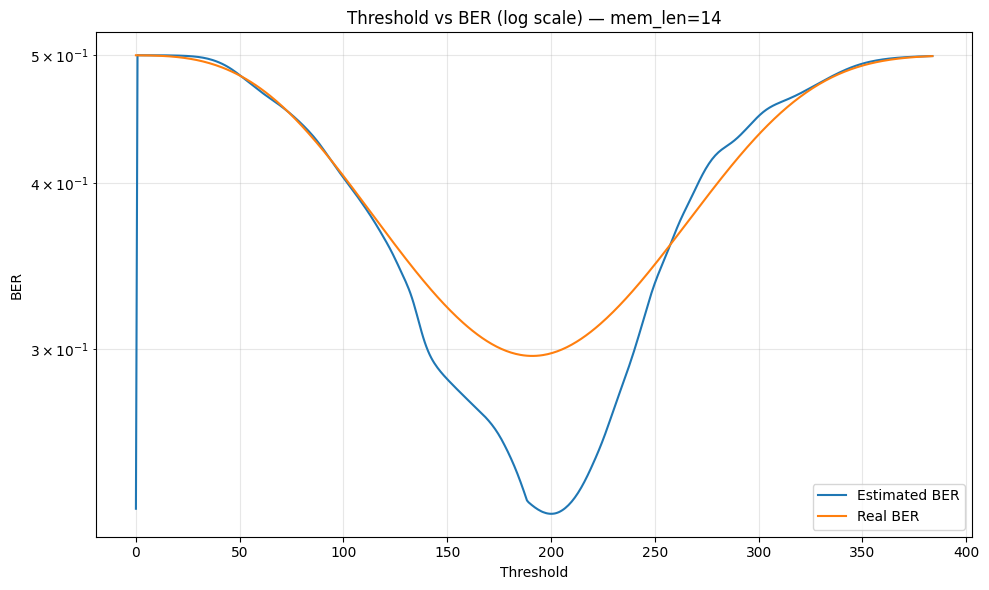

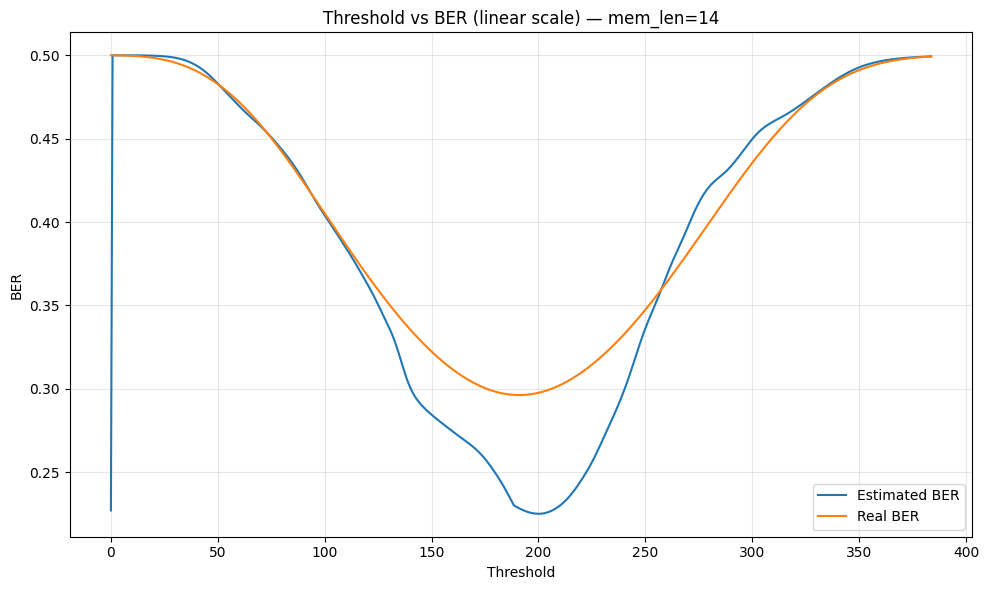

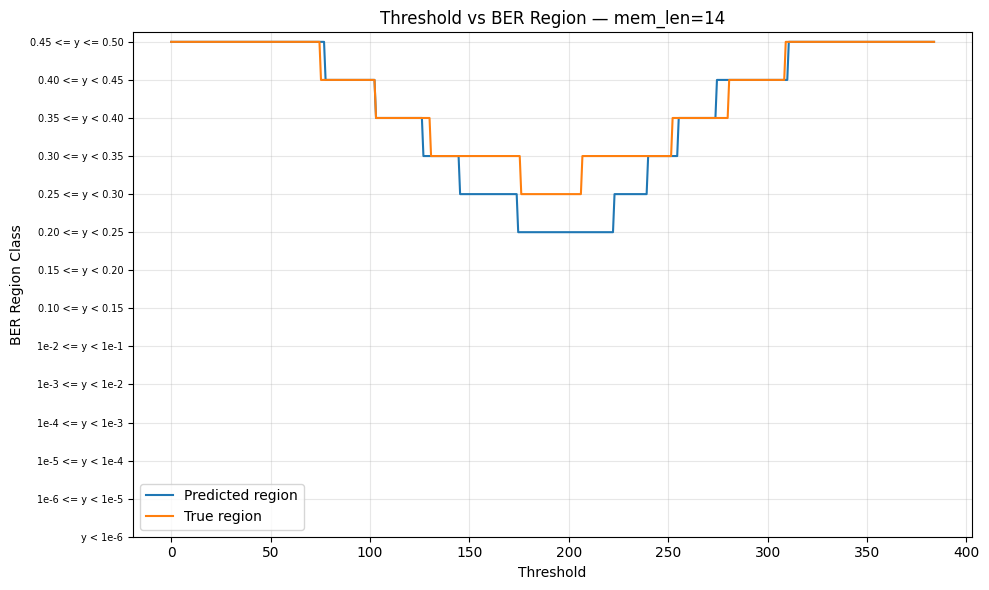

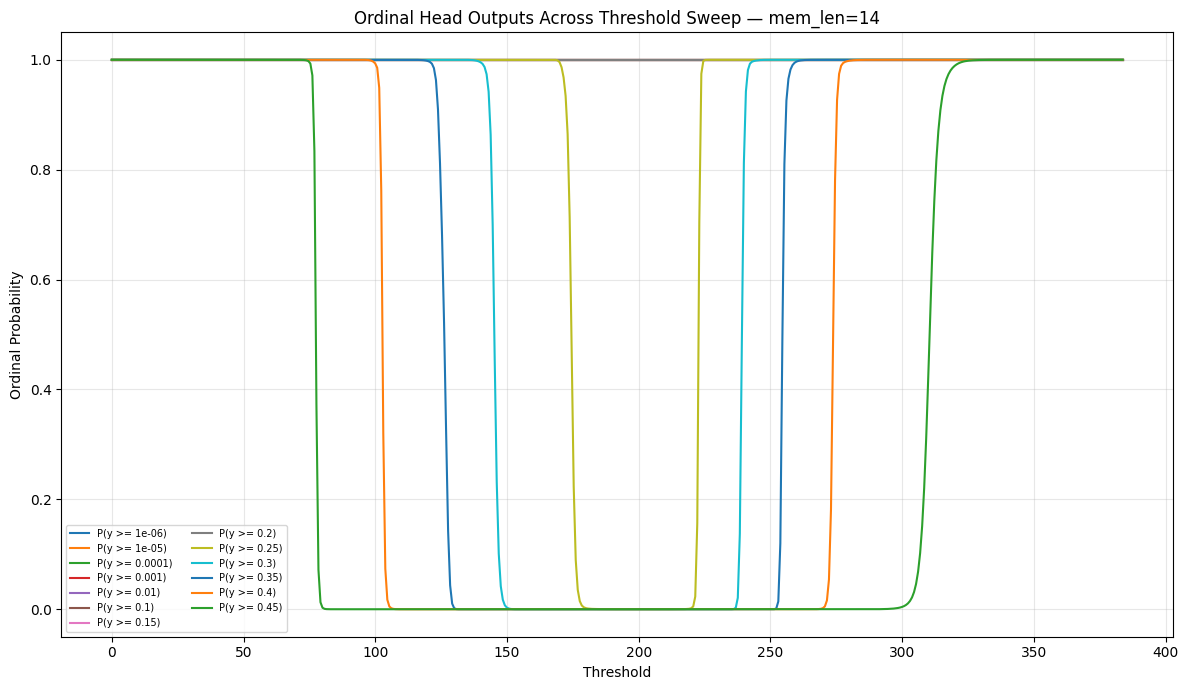

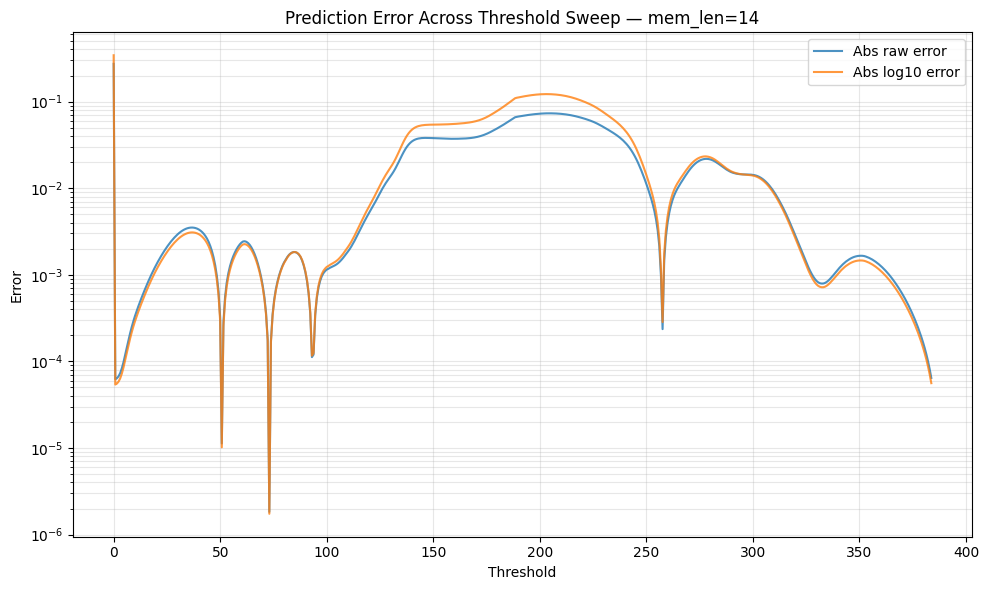

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# Must match training config
ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.10 <= y < 0.15",
    7: "0.15 <= y < 0.20",
    8: "0.20 <= y < 0.25",
    9: "0.25 <= y < 0.30",
    10: "0.30 <= y < 0.35",
    11: "0.35 <= y < 0.40",
    12: "0.40 <= y < 0.45",
    13: "0.45 <= y <= 0.50",
}


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def raw_to_region_labels_np(y_raw):
    """Region labels matching the 13-threshold ordinal scheme."""
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# Shared scaling helper (must match training code)
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000,
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Set-transformer model blocks (must match training code exactly)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)
        return pooled


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(num_set_layers)
        ])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Build inference inputs (position-independent scaling)
# =========================
def prepare_inference_features(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over a single physical case.

    Uses position-independent shared scalers — works for any mem_len,
    even beyond what the model saw during training.

    Args:
        case:       dict from generate_physical_case
        thresholds: 1-D array of threshold values to sweep
        scalers:    dict from joblib.load(SCALER_SAVE_PATH)
        device:     torch device

    Returns:
        first_t, past_t, global_t, thr_t, mask_t — all torch tensors on device
    """
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    # Raw tap and variance arrays for this scenario (1-D, length = mem_len)
    P_raw = np.asarray(case["P"], dtype=np.float32)         # [mem_len]
    var_raw = np.asarray(case["variances"], dtype=np.float32)  # [mem_len]
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)  # [B, 1]

    # Feature engineering (same as training)
    taps_feat = (P_raw * N).astype(np.float32)    # [mem_len]
    vars_feat = var_raw.astype(np.float32)         # [mem_len]
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    # Broadcast to [B, mem_len]
    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    past_lens = np.full(B, L_past, dtype=np.int64)  # all rows have same mem_len

    # Validity mask for past positions (all valid since no padding needed)
    valid_past = np.ones((B, L_past), dtype=bool)

    # --- Mask-aware global features ---
    first_mean = taps_2d[:, 0:1]          # [B, 1]
    past_means = taps_2d[:, 1:]           # [B, L_past]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    # All positions valid, so no masking needed for sums
    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # --- Scale first token (position-0 scaler) ---
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # --- Scale past tokens (shared position-independent scaler) ---
    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # --- Scale global features ---
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    # --- Scale threshold ---
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # --- Padding mask (no padding needed when L_past == actual past length) ---
    pad_mask = np.zeros((B, L_past), dtype=bool)  # all False = all valid

    # Convert to tensors
    first_t = torch.from_numpy(first_token).to(device)
    past_t = torch.from_numpy(past_tokens).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_s).to(device)
    mask_t = torch.from_numpy(pad_mask).to(device)

    return first_t, past_t, global_t, thr_t, mask_t


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE,
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep — ground truth
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"],
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

# Read metadata from scalers
max_past_seq_len = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", case["mem_len"] - 1))
ordinal_thresholds = scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)
num_ordinal = len(ordinal_thresholds)

model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
    max_past_seq_len=max_past_seq_len,
    token_dim=scalers.get("past_token_dim", 4),
    first_token_dim=scalers.get("first_token_dim", 4),
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    d_model=128,
    num_set_layers=4,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.10,
    num_ordinal_thresholds=num_ordinal,
).to(device)

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print(f"\nModel loaded: max_past_seq_len={max_past_seq_len}, ordinal_thresholds={num_ordinal}")
print(f"Scaling strategy: {scalers.get('scaling_strategy', 'unknown')}")

# =========================
# Predict across thresholds
# =========================
first_t, past_t, global_t, thr_t, mask_t = prepare_inference_features(
    case, thresholds, scalers, device,
)

with torch.no_grad():
    pred_raw_out, ord_logits = model(
        first_t, past_t, global_t, thr_t, key_padding_mask=mask_t,
    )
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions.astype(np.int64) - real_regions.astype(np.int64)),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS.get(int(real_regions[best_real_idx]), "?"))

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS.get(int(pred_regions[best_est_idx]), "?"))

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region — mem_len={case['mem_len']}")
plt.yticks(list(REGION_LABELS.keys()), [REGION_LABELS[k] for k in sorted(REGION_LABELS.keys())],
           fontsize=7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr_val in enumerate(ordinal_thresholds):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr_val:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 5: absolute error by region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["abs_error"], label="Abs raw error", alpha=0.8)
plt.plot(results["threshold"], results["abs_log10_error"], label="Abs log10 error", alpha=0.8)
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(f"Prediction Error Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Generated physical scenario
radius    = 3.525878070651803
distance  = 14.99026827911803
diffusion = 50.72752481410604
Ts        = 1.0687791129906388
N         = 26351
mem_len   = 14
P         = [0.02856194 0.03022432 0.01850619 0.01252221 0.00914988 0.00705016
 0.0056433  0.00464789 0.00391361 0.00335388 0.00291575 0.00256526
 0.0022797  0.00204341]
P_scaled  = [752.63578016 796.44110411 487.65655413 329.97284647 241.10838115
 185.77880799 148.70657192 122.47646652 103.1274684   88.37804227
  76.83304759  67.59713225  60.07238286  53.84601272]
variances = [731.13903933 772.36921188 478.63189037 325.84085606 238.90226938
 184.46903738 147.86737628 121.90720976 102.72386798  88.08163308
  76.60902129  67.42372811  59.93543583  53.73598301]
Threshold search interval: 0.0 to 3514.630598565405
sum(P_scaled) = 3514.630598565405

Model loaded: max_past_seq_len=13, ordinal_thresholds=13
Scaling strategy: position_independent
    threshold  real_BER  estimated_BER  real_region  predicted_region

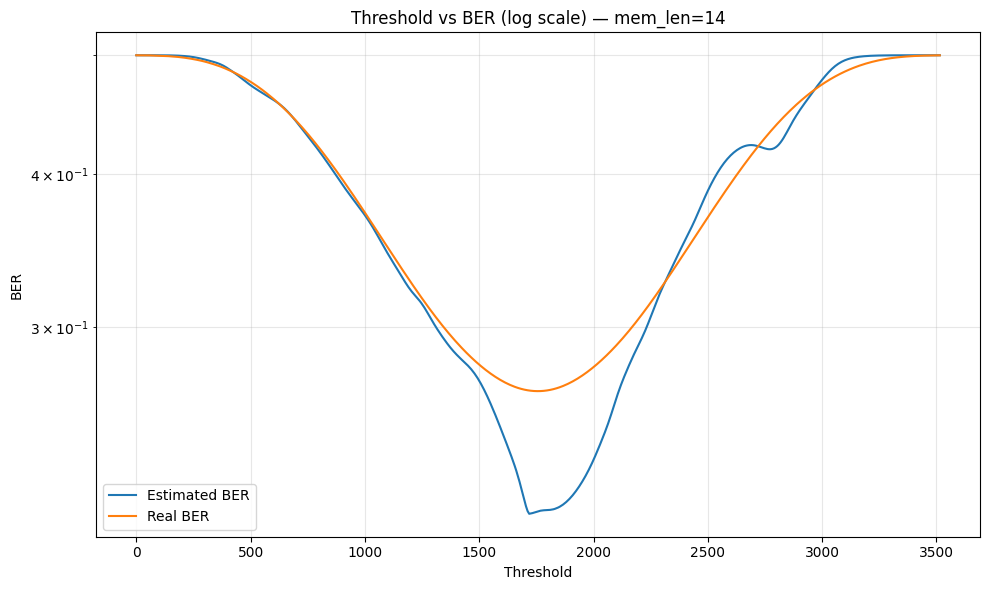

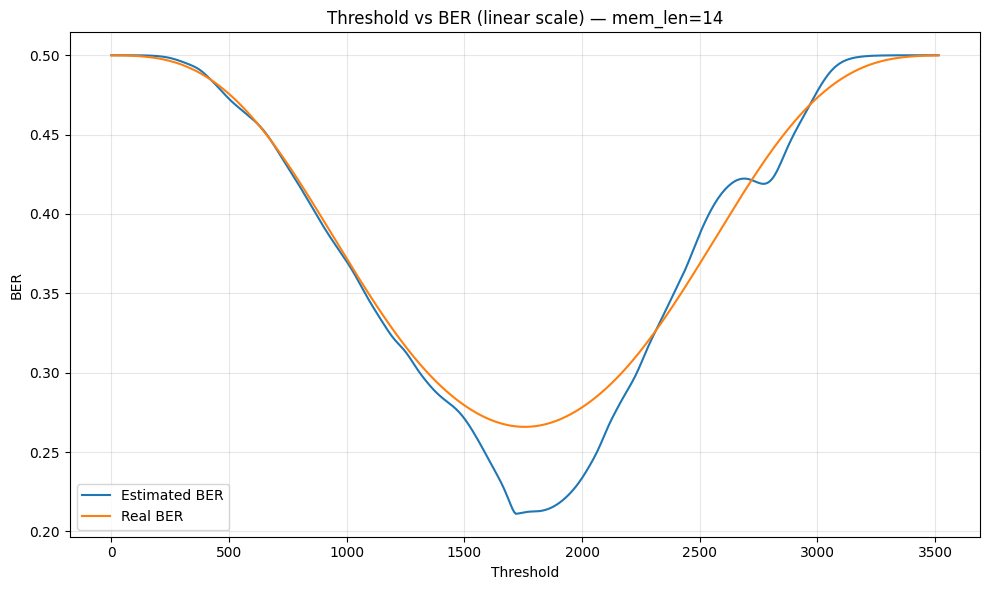

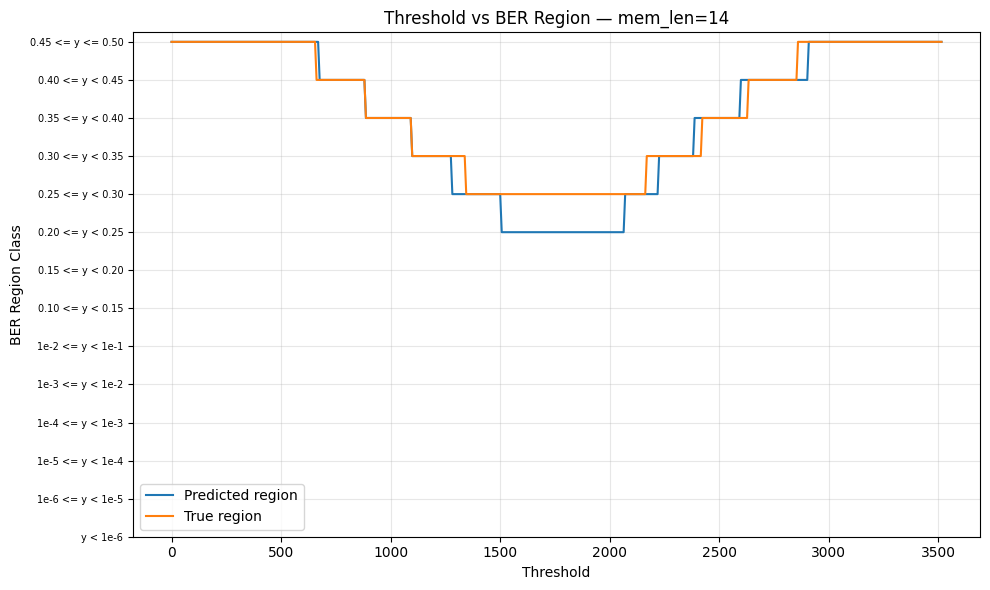

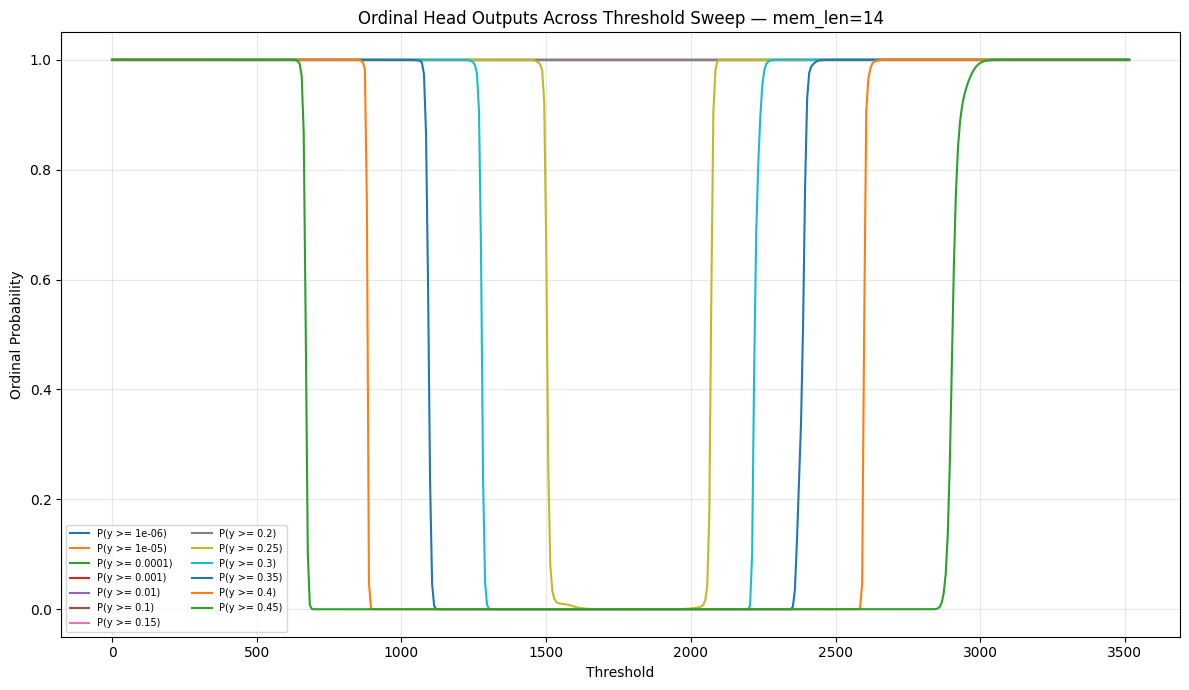

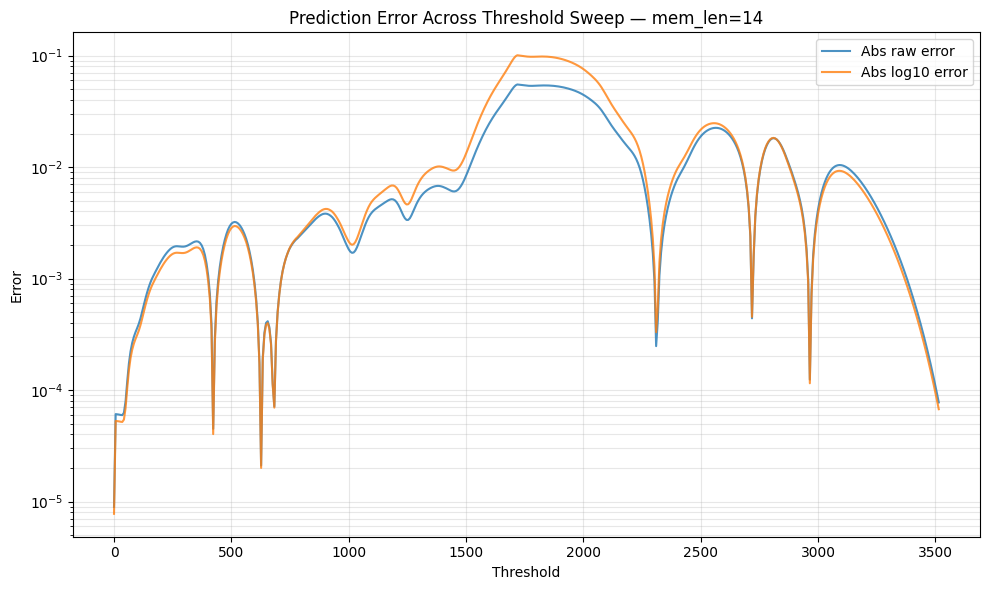

In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# Must match training config
ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.10 <= y < 0.15",
    7: "0.15 <= y < 0.20",
    8: "0.20 <= y < 0.25",
    9: "0.25 <= y < 0.30",
    10: "0.30 <= y < 0.35",
    11: "0.35 <= y < 0.40",
    12: "0.40 <= y < 0.45",
    13: "0.45 <= y <= 0.50",
}


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def raw_to_region_labels_np(y_raw):
    """Region labels matching the 13-threshold ordinal scheme."""
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# Shared scaling helper (must match training code)
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000,
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(1, 2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Set-transformer model blocks (must match training code exactly)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)
        return pooled


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(num_set_layers)
        ])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Build inference inputs (position-independent scaling)
# =========================
def prepare_inference_features(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over a single physical case.

    Uses position-independent shared scalers — works for any mem_len,
    even beyond what the model saw during training.

    Args:
        case:       dict from generate_physical_case
        thresholds: 1-D array of threshold values to sweep
        scalers:    dict from joblib.load(SCALER_SAVE_PATH)
        device:     torch device

    Returns:
        first_t, past_t, global_t, thr_t, mask_t — all torch tensors on device
    """
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    # Raw tap and variance arrays for this scenario (1-D, length = mem_len)
    P_raw = np.asarray(case["P"], dtype=np.float32)         # [mem_len]
    var_raw = np.asarray(case["variances"], dtype=np.float32)  # [mem_len]
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)  # [B, 1]

    # Feature engineering (same as training)
    taps_feat = (P_raw * N).astype(np.float32)    # [mem_len]
    vars_feat = var_raw.astype(np.float32)         # [mem_len]
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    # Broadcast to [B, mem_len]
    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    past_lens = np.full(B, L_past, dtype=np.int64)  # all rows have same mem_len

    # Validity mask for past positions (all valid since no padding needed)
    valid_past = np.ones((B, L_past), dtype=bool)

    # --- Mask-aware global features ---
    first_mean = taps_2d[:, 0:1]          # [B, 1]
    past_means = taps_2d[:, 1:]           # [B, L_past]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    # All positions valid, so no masking needed for sums
    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # --- Scale first token (position-0 scaler) ---
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # --- Scale past tokens (shared position-independent scaler) ---
    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # --- Scale global features ---
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    # --- Scale threshold ---
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # --- Padding mask (no padding needed when L_past == actual past length) ---
    pad_mask = np.zeros((B, L_past), dtype=bool)  # all False = all valid

    # Convert to tensors
    first_t = torch.from_numpy(first_token).to(device)
    past_t = torch.from_numpy(past_tokens).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_s).to(device)
    mask_t = torch.from_numpy(pad_mask).to(device)

    return first_t, past_t, global_t, thr_t, mask_t


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE,
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep — ground truth
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"],
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

# Read metadata from scalers
max_past_seq_len = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", case["mem_len"] - 1))
ordinal_thresholds = scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)
num_ordinal = len(ordinal_thresholds)

model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
    max_past_seq_len=max_past_seq_len,
    token_dim=scalers.get("past_token_dim", 4),
    first_token_dim=scalers.get("first_token_dim", 4),
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    d_model=128,
    num_set_layers=4,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.10,
    num_ordinal_thresholds=num_ordinal,
).to(device)

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print(f"\nModel loaded: max_past_seq_len={max_past_seq_len}, ordinal_thresholds={num_ordinal}")
print(f"Scaling strategy: {scalers.get('scaling_strategy', 'unknown')}")

# =========================
# Predict across thresholds
# =========================
first_t, past_t, global_t, thr_t, mask_t = prepare_inference_features(
    case, thresholds, scalers, device,
)

with torch.no_grad():
    pred_raw_out, ord_logits = model(
        first_t, past_t, global_t, thr_t, key_padding_mask=mask_t,
    )
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions.astype(np.int64) - real_regions.astype(np.int64)),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS.get(int(real_regions[best_real_idx]), "?"))

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS.get(int(pred_regions[best_est_idx]), "?"))

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region — mem_len={case['mem_len']}")
plt.yticks(list(REGION_LABELS.keys()), [REGION_LABELS[k] for k in sorted(REGION_LABELS.keys())],
           fontsize=7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr_val in enumerate(ordinal_thresholds):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr_val:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 5: absolute error by region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["abs_error"], label="Abs raw error", alpha=0.8)
plt.plot(results["threshold"], results["abs_log10_error"], label="Abs log10 error", alpha=0.8)
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(f"Prediction Error Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Generated physical scenario
radius    = 4.101060336906475
distance  = 14.840922996202488
diffusion = 74.78839777698568
Ts        = 3.3932544989631195
N         = 9093
mem_len   = 3
P         = [0.11043046 0.02842677 0.0134985 ]
P_scaled  = [1004.14416896  258.48464169  122.74187047]
variances = [893.2560669 251.1367576 121.0850392]
Threshold search interval: 0.0 to 1385.3706811203776
sum(P_scaled) = 1385.3706811203776

Model loaded: max_past_seq_len=13, ordinal_thresholds=13
Scaling strategy: position_independent
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000     0.500       0.000095           13                10   
1    2.776294     0.375       0.362869           11                11   
2    5.552588     0.375       0.362844           11                11   
3    8.328882     0.375       0.362998           11                11   
4   11.105176     0.375       0.363256           11                11   
5   13.881470     0.375       0.363651     

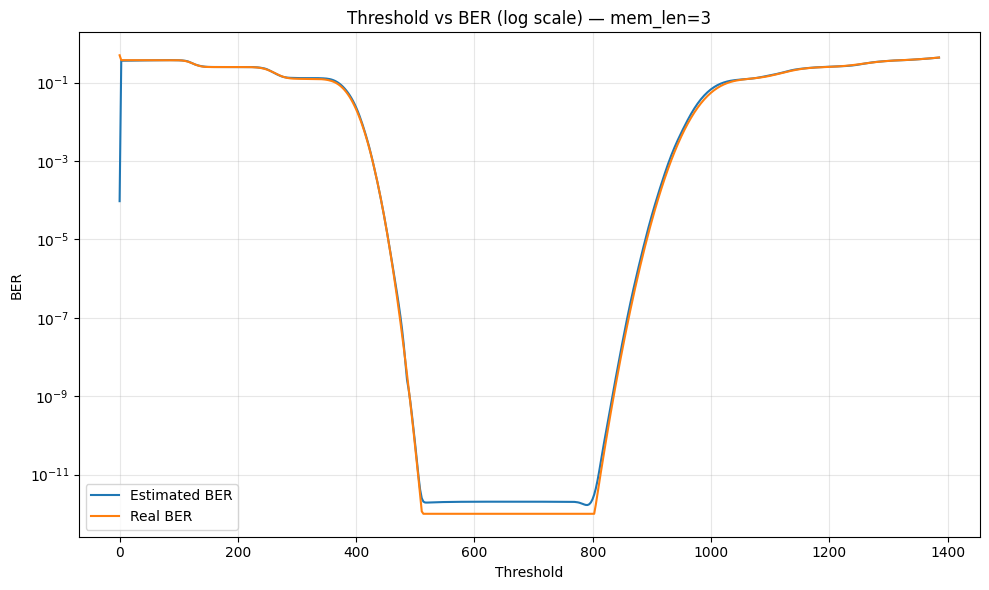

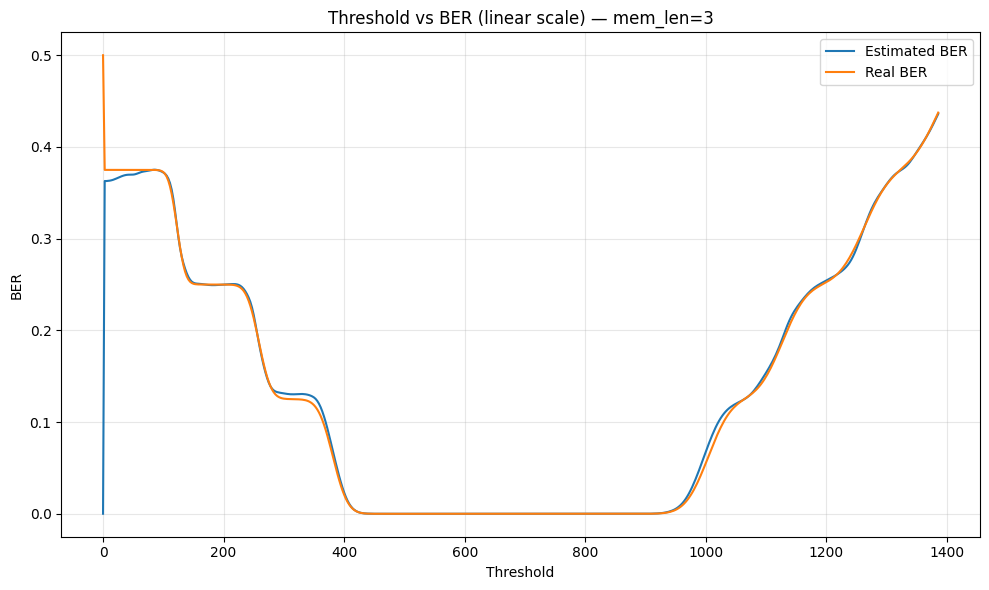

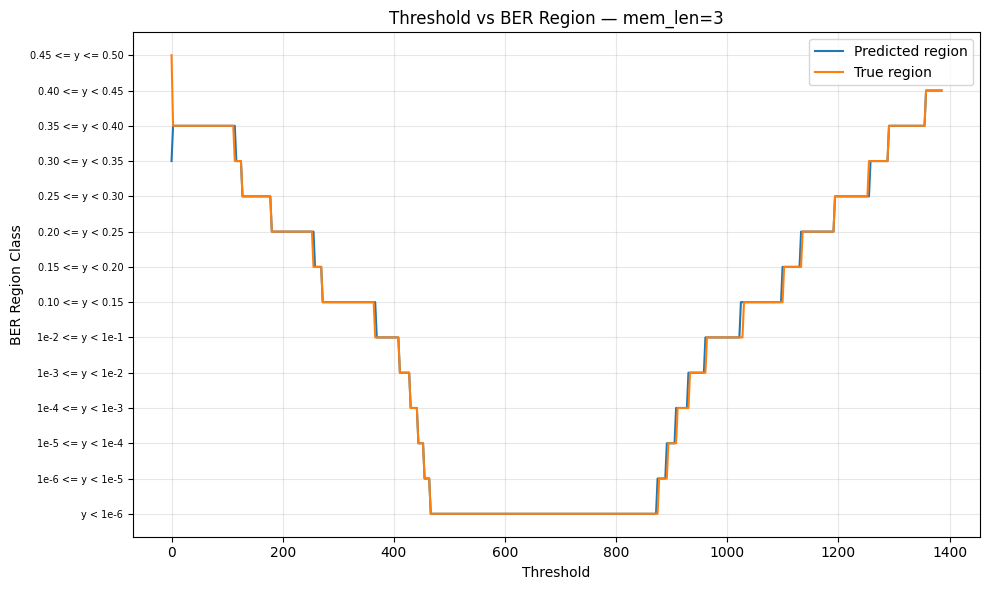

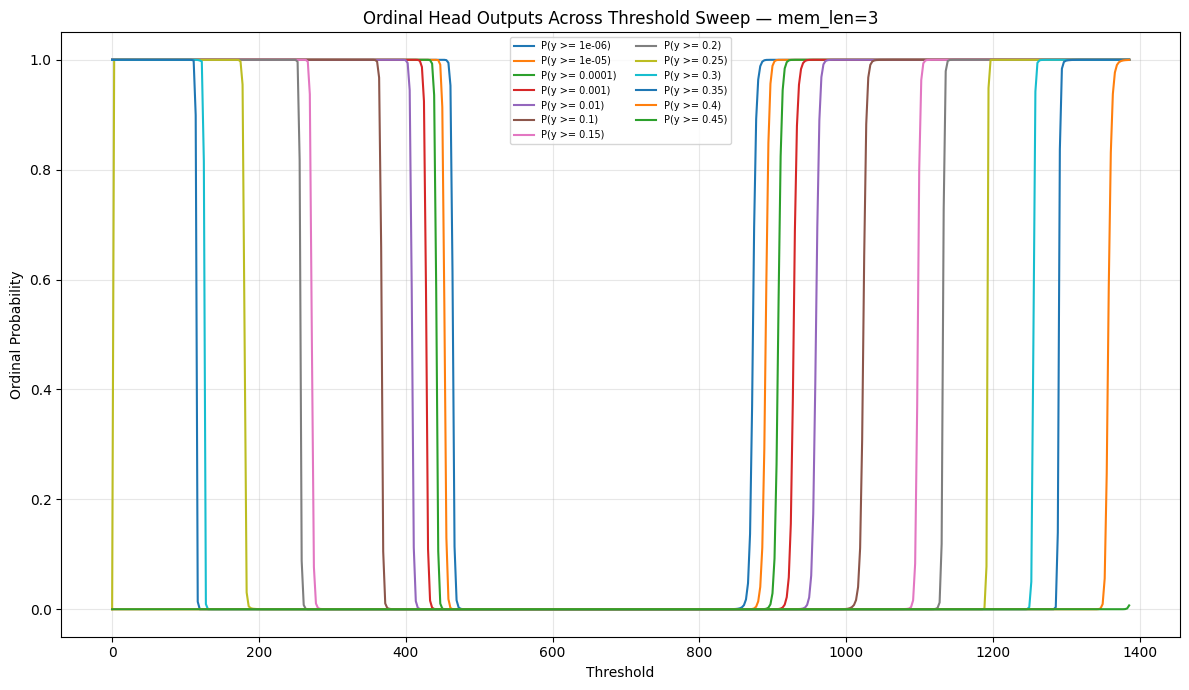

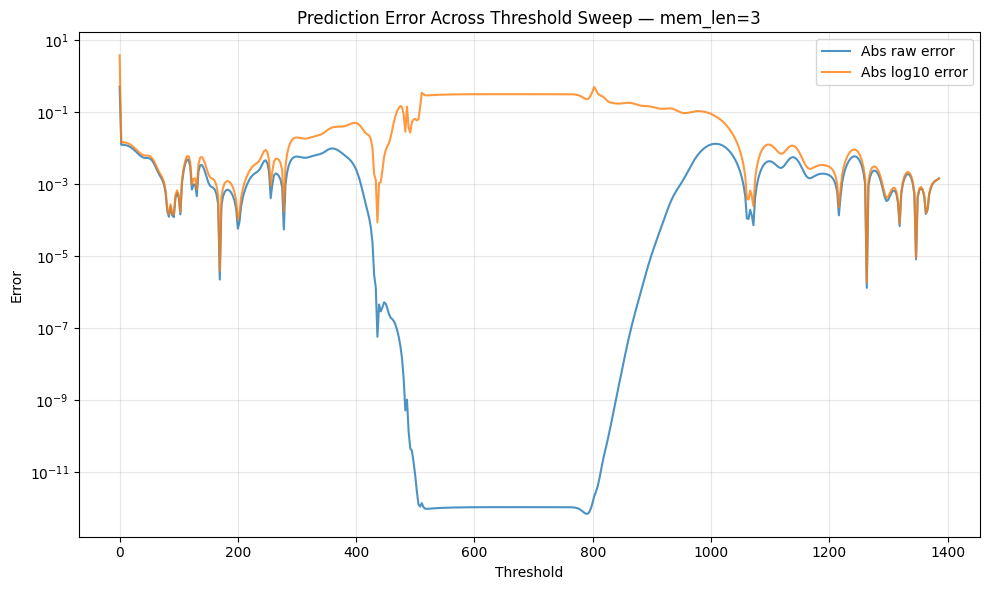

In [7]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# Must match training config
ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.10 <= y < 0.15",
    7: "0.15 <= y < 0.20",
    8: "0.20 <= y < 0.25",
    9: "0.25 <= y < 0.30",
    10: "0.30 <= y < 0.35",
    11: "0.35 <= y < 0.40",
    12: "0.40 <= y < 0.45",
    13: "0.45 <= y <= 0.50",
}


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def raw_to_region_labels_np(y_raw):
    """Region labels matching the 13-threshold ordinal scheme."""
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# Shared scaling helper (must match training code)
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=3,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000,
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(3, 4)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Set-transformer model blocks (must match training code exactly)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)
        return pooled


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(num_set_layers)
        ])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Build inference inputs (position-independent scaling)
# =========================
def prepare_inference_features(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over a single physical case.

    Uses position-independent shared scalers — works for any mem_len,
    even beyond what the model saw during training.

    Args:
        case:       dict from generate_physical_case
        thresholds: 1-D array of threshold values to sweep
        scalers:    dict from joblib.load(SCALER_SAVE_PATH)
        device:     torch device

    Returns:
        first_t, past_t, global_t, thr_t, mask_t — all torch tensors on device
    """
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    # Raw tap and variance arrays for this scenario (1-D, length = mem_len)
    P_raw = np.asarray(case["P"], dtype=np.float32)         # [mem_len]
    var_raw = np.asarray(case["variances"], dtype=np.float32)  # [mem_len]
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)  # [B, 1]

    # Feature engineering (same as training)
    taps_feat = (P_raw * N).astype(np.float32)    # [mem_len]
    vars_feat = var_raw.astype(np.float32)         # [mem_len]
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    # Broadcast to [B, mem_len]
    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    past_lens = np.full(B, L_past, dtype=np.int64)  # all rows have same mem_len

    # Validity mask for past positions (all valid since no padding needed)
    valid_past = np.ones((B, L_past), dtype=bool)

    # --- Mask-aware global features ---
    first_mean = taps_2d[:, 0:1]          # [B, 1]
    past_means = taps_2d[:, 1:]           # [B, L_past]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    # All positions valid, so no masking needed for sums
    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # --- Scale first token (position-0 scaler) ---
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # --- Scale past tokens (shared position-independent scaler) ---
    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # --- Scale global features ---
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    # --- Scale threshold ---
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # --- Padding mask (no padding needed when L_past == actual past length) ---
    pad_mask = np.zeros((B, L_past), dtype=bool)  # all False = all valid

    # Convert to tensors
    first_t = torch.from_numpy(first_token).to(device)
    past_t = torch.from_numpy(past_tokens).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_s).to(device)
    mask_t = torch.from_numpy(pad_mask).to(device)

    return first_t, past_t, global_t, thr_t, mask_t


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE,
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep — ground truth
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"],
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

# Read metadata from scalers
max_past_seq_len = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", case["mem_len"] - 1))
ordinal_thresholds = scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)
num_ordinal = len(ordinal_thresholds)

model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
    max_past_seq_len=max_past_seq_len,
    token_dim=scalers.get("past_token_dim", 4),
    first_token_dim=scalers.get("first_token_dim", 4),
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    d_model=128,
    num_set_layers=4,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.10,
    num_ordinal_thresholds=num_ordinal,
).to(device)

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print(f"\nModel loaded: max_past_seq_len={max_past_seq_len}, ordinal_thresholds={num_ordinal}")
print(f"Scaling strategy: {scalers.get('scaling_strategy', 'unknown')}")

# =========================
# Predict across thresholds
# =========================
first_t, past_t, global_t, thr_t, mask_t = prepare_inference_features(
    case, thresholds, scalers, device,
)

with torch.no_grad():
    pred_raw_out, ord_logits = model(
        first_t, past_t, global_t, thr_t, key_padding_mask=mask_t,
    )
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions.astype(np.int64) - real_regions.astype(np.int64)),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS.get(int(real_regions[best_real_idx]), "?"))

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS.get(int(pred_regions[best_est_idx]), "?"))

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region — mem_len={case['mem_len']}")
plt.yticks(list(REGION_LABELS.keys()), [REGION_LABELS[k] for k in sorted(REGION_LABELS.keys())],
           fontsize=7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr_val in enumerate(ordinal_thresholds):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr_val:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 5: absolute error by region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["abs_error"], label="Abs raw error", alpha=0.8)
plt.plot(results["threshold"], results["abs_log10_error"], label="Abs log10 error", alpha=0.8)
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(f"Prediction Error Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Generated physical scenario
radius    = 4.101060336906475
distance  = 14.840922996202488
diffusion = 74.78839777698568
Ts        = 2.1797634968893584
N         = 9093
mem_len   = 5
P         = [0.0890119  0.03247428 0.01602182 0.00995572 0.00694744]
P_scaled  = [809.38519731 295.28863578 145.68643337  90.52733491  63.17307764]
variances = [737.3402839  285.69934969 143.35227117  89.62607039  62.73418643]
Threshold search interval: 0.0 to 1404.0606790062445
sum(P_scaled) = 1404.0606790062445

Model loaded: max_past_seq_len=13, ordinal_thresholds=13
Scaling strategy: position_independent
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000  0.500000       0.000350           13                12   
1    2.813749  0.468750       0.473014           13                13   
2    5.627498  0.468750       0.470601           13                13   
3    8.441247  0.468750       0.470099           13                13   
4   11.254995  0.468750       0.469993    

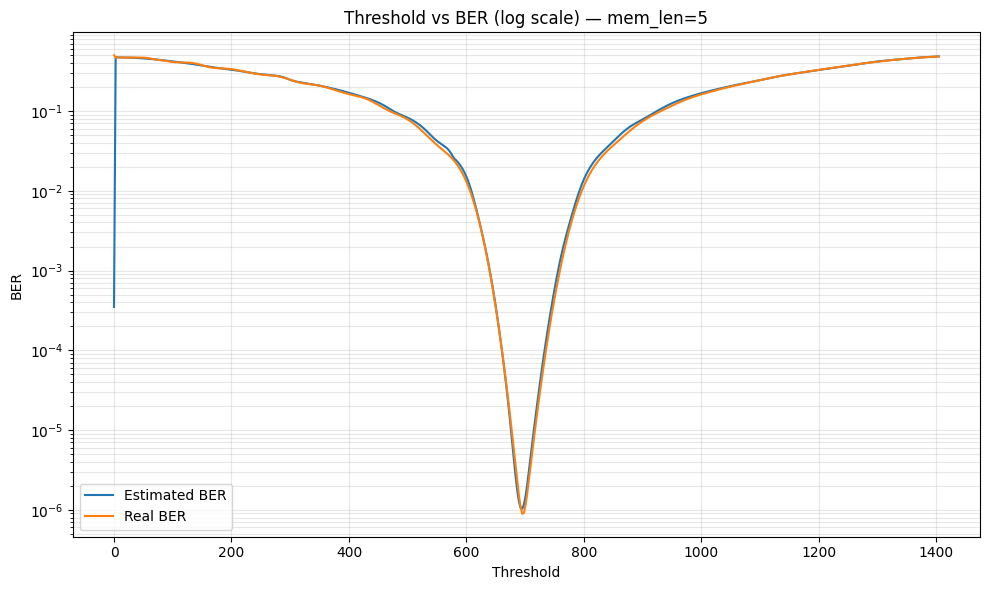

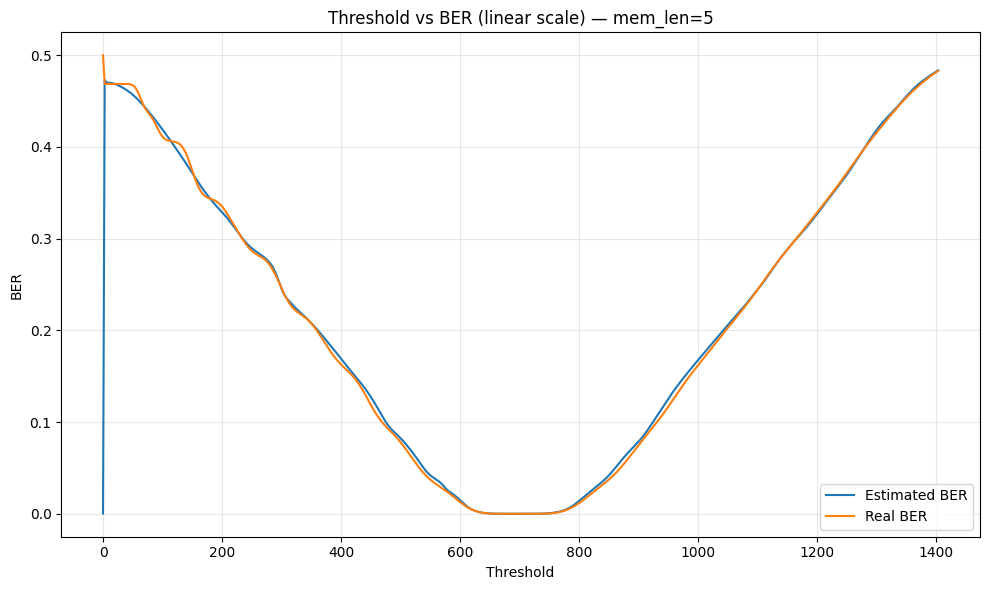

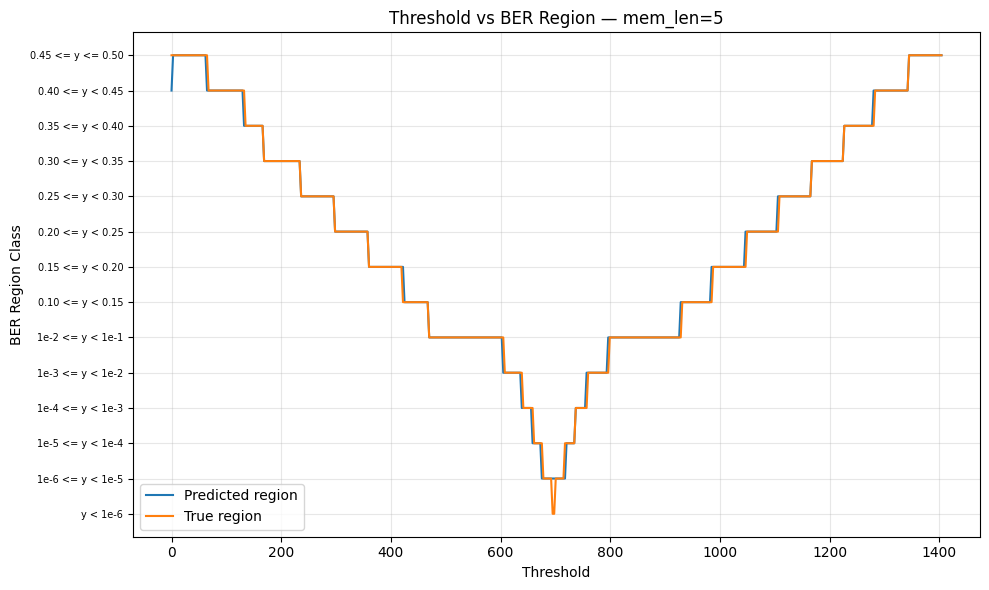

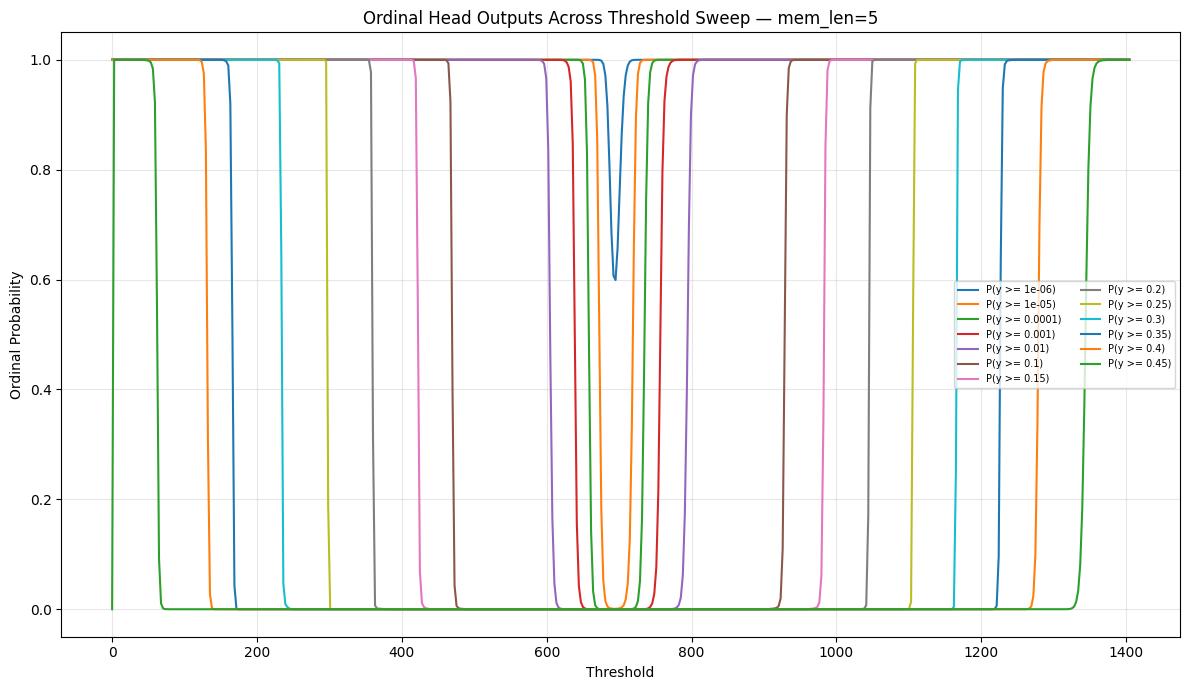

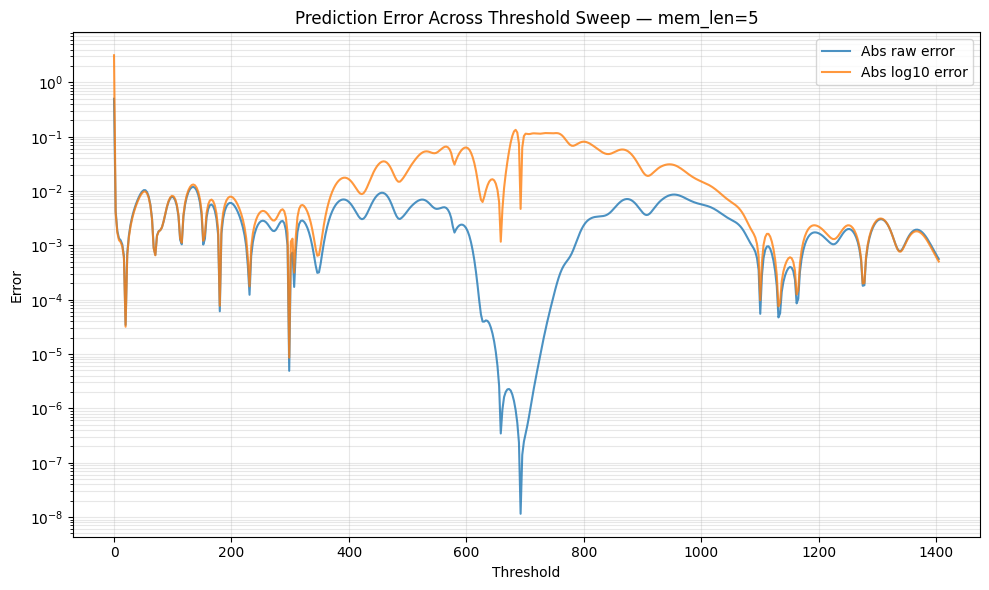

In [8]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# Must match training config
ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.10 <= y < 0.15",
    7: "0.15 <= y < 0.20",
    8: "0.20 <= y < 0.25",
    9: "0.25 <= y < 0.30",
    10: "0.30 <= y < 0.35",
    11: "0.35 <= y < 0.40",
    12: "0.40 <= y < 0.45",
    13: "0.45 <= y <= 0.50",
}


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def raw_to_region_labels_np(y_raw):
    """Region labels matching the 13-threshold ordinal scheme."""
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# Shared scaling helper (must match training code)
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=3,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000,
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(1, 4)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Set-transformer model blocks (must match training code exactly)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)
        return pooled


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(num_set_layers)
        ])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Build inference inputs (position-independent scaling)
# =========================
def prepare_inference_features(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over a single physical case.

    Uses position-independent shared scalers — works for any mem_len,
    even beyond what the model saw during training.

    Args:
        case:       dict from generate_physical_case
        thresholds: 1-D array of threshold values to sweep
        scalers:    dict from joblib.load(SCALER_SAVE_PATH)
        device:     torch device

    Returns:
        first_t, past_t, global_t, thr_t, mask_t — all torch tensors on device
    """
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    # Raw tap and variance arrays for this scenario (1-D, length = mem_len)
    P_raw = np.asarray(case["P"], dtype=np.float32)         # [mem_len]
    var_raw = np.asarray(case["variances"], dtype=np.float32)  # [mem_len]
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)  # [B, 1]

    # Feature engineering (same as training)
    taps_feat = (P_raw * N).astype(np.float32)    # [mem_len]
    vars_feat = var_raw.astype(np.float32)         # [mem_len]
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    # Broadcast to [B, mem_len]
    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    past_lens = np.full(B, L_past, dtype=np.int64)  # all rows have same mem_len

    # Validity mask for past positions (all valid since no padding needed)
    valid_past = np.ones((B, L_past), dtype=bool)

    # --- Mask-aware global features ---
    first_mean = taps_2d[:, 0:1]          # [B, 1]
    past_means = taps_2d[:, 1:]           # [B, L_past]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    # All positions valid, so no masking needed for sums
    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # --- Scale first token (position-0 scaler) ---
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # --- Scale past tokens (shared position-independent scaler) ---
    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # --- Scale global features ---
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    # --- Scale threshold ---
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # --- Padding mask (no padding needed when L_past == actual past length) ---
    pad_mask = np.zeros((B, L_past), dtype=bool)  # all False = all valid

    # Convert to tensors
    first_t = torch.from_numpy(first_token).to(device)
    past_t = torch.from_numpy(past_tokens).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_s).to(device)
    mask_t = torch.from_numpy(pad_mask).to(device)

    return first_t, past_t, global_t, thr_t, mask_t


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE,
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep — ground truth
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"],
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

# Read metadata from scalers
max_past_seq_len = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", case["mem_len"] - 1))
ordinal_thresholds = scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)
num_ordinal = len(ordinal_thresholds)

model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
    max_past_seq_len=max_past_seq_len,
    token_dim=scalers.get("past_token_dim", 4),
    first_token_dim=scalers.get("first_token_dim", 4),
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    d_model=128,
    num_set_layers=4,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.10,
    num_ordinal_thresholds=num_ordinal,
).to(device)

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print(f"\nModel loaded: max_past_seq_len={max_past_seq_len}, ordinal_thresholds={num_ordinal}")
print(f"Scaling strategy: {scalers.get('scaling_strategy', 'unknown')}")

# =========================
# Predict across thresholds
# =========================
first_t, past_t, global_t, thr_t, mask_t = prepare_inference_features(
    case, thresholds, scalers, device,
)

with torch.no_grad():
    pred_raw_out, ord_logits = model(
        first_t, past_t, global_t, thr_t, key_padding_mask=mask_t,
    )
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions.astype(np.int64) - real_regions.astype(np.int64)),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS.get(int(real_regions[best_real_idx]), "?"))

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS.get(int(pred_regions[best_est_idx]), "?"))

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region — mem_len={case['mem_len']}")
plt.yticks(list(REGION_LABELS.keys()), [REGION_LABELS[k] for k in sorted(REGION_LABELS.keys())],
           fontsize=7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr_val in enumerate(ordinal_thresholds):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr_val:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Plot 5: absolute error by region
# =========================
plt.figure(figsize=(10, 6))3
plt.plot(results["threshold"], results["abs_error"], label="Abs raw error", alpha=0.8)
plt.plot(results["threshold"], results["abs_log10_error"], label="Abs log10 error", alpha=0.8)
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(f"Prediction Error Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Scenario Difficulty

In [9]:
"""
Scenario Difficulty Diagnostics
===============================
Evaluate model performance stratified by threshold-INDEPENDENT scenario
difficulty metrics.  The goal is to find which physical configurations are
hard for the model, so we can improve sampling / weighting in training.

Key difficulty features (all computed WITHOUT the threshold):

1. SIR  = P_0*N / sum(P_i*N, i>=1)
        Signal-to-interference ratio.  Low SIR = hard.

2. ISI_spread = std0 / (mu1 - mu0)
        How wide the ISI noise is relative to the gap between the
        "0-sent" and "1-sent" distribution means.
        mu0 = 0.5 * sum(P_i*N, i>=1)   (mean received when current bit=0)
        mu1 = P_0*N + mu0              (mean received when current bit=1)
        High ISI_spread = hard.

3. distribution_overlap = 2 * Phi(-d/2) where d = |mu1-mu0| / sqrt((var0+var1)/2)
        The Bayes-optimal error rate for two Gaussians (ignoring threshold).
        High overlap = hard.

4. effective_snr = (mu1 - mu0)^2 / (var0 + var1)
        Fisher discriminant.  Low effective_snr = hard.

5. mem_len itself — longer memory = more ISI contributors.

For each metric we bin scenarios into quantiles and report per-bin
model error statistics, including P90/P95 tails and bias.
"""

import os
import sys
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.stats import norm
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths — update these
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"
OUTPUT_DIR = "./difficulty_diagnostics"

# =========================
# Config
# =========================
N_SCENARIOS = 200           # number of random physical scenarios to generate
N_THRESHOLDS_PER_SCENARIO = 200  # threshold sweep density per scenario
RANDOM_SEED = 42

# Scenario generation ranges
MEM_LEN_MIN = 4
MEM_LEN_MAX = 14
ARRIVAL_COVERAGE = 0.70

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(
        distance / np.sqrt(4 * diffusionCoef * t)
    )


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = std == 0
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )
    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) / (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) / (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


# =========================
# Scenario difficulty metrics (threshold-independent)
# =========================
def compute_scenario_difficulty(P_scaled, variances):
    """Compute threshold-independent difficulty metrics for a scenario.

    Args:
        P_scaled:  [mem_len] array = P * N
        variances: [mem_len] array = N * P * (1-P)

    Returns:
        dict of scalar difficulty metrics
    """
    signal = P_scaled[0]                          # first tap = signal
    isi_total = np.sum(P_scaled[1:])              # total ISI contribution
    isi_var_total = np.sum(variances[1:])         # total ISI variance

    # Means of the two hypotheses (bit=0 vs bit=1)
    mu0 = 0.5 * isi_total                         # E[received | current=0]
    mu1 = signal + mu0                             # E[received | current=1]
    gap = mu1 - mu0                                # = signal = P_0 * N

    # Variances
    var0 = 0.5 * isi_var_total                     # Var[received | current=0]
    var1 = variances[0] + var0                     # Var[received | current=1]

    std0 = np.sqrt(max(var0, EPS))
    std1 = np.sqrt(max(var1, EPS))

    # 1. SIR: signal / interference
    sir = signal / max(isi_total, EPS)

    # 2. ISI spread: how wide ISI noise is relative to gap
    isi_spread = std0 / max(gap, EPS)

    # 3. Distribution overlap: Bhattacharyya-like
    #    For two Gaussians N(mu0,var0) and N(mu1,var1),
    #    the optimal error is bounded by overlap = 2*Phi(-d/2)
    #    where d = |mu1-mu0| / sqrt((var0+var1)/2)
    avg_var = (var0 + var1) / 2.0
    d_fisher = abs(gap) / np.sqrt(max(avg_var, EPS))
    overlap = 2.0 * norm.cdf(-d_fisher / 2.0)

    # 4. Effective SNR (Fisher discriminant ratio)
    effective_snr = gap ** 2 / max(var0 + var1, EPS)

    # 5. Coefficient of variation of ISI taps (how uneven ISI is)
    past_taps = P_scaled[1:]
    if len(past_taps) > 1:
        isi_cv = float(np.std(past_taps) / max(np.mean(past_taps), EPS))
    else:
        isi_cv = 0.0

    # 6. Dominant ISI ratio: largest single ISI tap / total ISI
    if len(past_taps) > 0 and isi_total > EPS:
        dominant_isi_ratio = float(np.max(past_taps) / isi_total)
    else:
        dominant_isi_ratio = 0.0

    return {
        "sir": float(sir),
        "isi_spread": float(isi_spread),
        "overlap": float(overlap),
        "effective_snr": float(effective_snr),
        "isi_cv": float(isi_cv),
        "dominant_isi_ratio": float(dominant_isi_ratio),
        "gap": float(gap),
        "mu0": float(mu0),
        "mu1": float(mu1),
        "std0": float(std0),
        "std1": float(std1),
    }


# =========================
# Generate scenarios
# =========================
def generate_physical_case(rng, min_mem_len, max_mem_len, arrival_coverage, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
        }

    raise RuntimeError(f"Could not generate case with mem_len >= {min_mem_len}")


# =========================
# Model definition (must match training code)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)
        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False, key_padding_mask=key_padding_mask)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)
        if key_padding_mask is not None:
            logits = logits.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)
        return (weights * x).sum(dim=1)


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(self, max_past_seq_len, token_dim=4, first_token_dim=4,
                 threshold_dim=1, global_dim=3, d_model=128, num_set_layers=4,
                 num_heads=4, mlp_ratio=4.0, dropout=0.10,
                 num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS):
        super().__init__()
        self.max_past_seq_len = max_past_seq_len
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(dropout),
        )
        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(dropout),
        )
        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32), nn.GELU(), nn.Linear(32, 32), nn.GELU(),
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU(),
        )

        cond_dim = 32 + 64
        self.first_cond_mod = ConditionalFeatureModulation(cond_dim, d_model, 256)
        self.set_cond_mod = ConditionalFeatureModulation(cond_dim, d_model, 256)

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(num_set_layers)
        ])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, d_model),
        )
        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model, 128)

        head_in = d_model + 3 * d_model + cond_dim
        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.15), nn.Linear(128, 1),
        )
        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(x):
        log10_half = torch.log10(torch.tensor(0.5, device=x.device, dtype=x.dtype))
        return log10_half - F.softplus(x)

    @staticmethod
    def raw_to_ber(x):
        return torch.pow(10.0, BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(x)).clamp(EPS, 0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)
        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)
        set_x = self.final_set_norm(set_x)

        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()
        else:
            valid_mask = torch.ones(set_x.shape[0], set_x.shape[1], 1,
                                    device=set_x.device, dtype=set_x.dtype)

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)
        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = torch.nan_to_num(x_for_max.amax(dim=1), nan=0.0, posinf=0.0, neginf=0.0)

        fused = torch.cat([first_x, pooled_attn, pooled_mean, pooled_max, cond], dim=-1)
        return self.reg_head(fused), self.ord_head(fused)


# =========================
# Scaling helper
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


def prepare_inference_tensors(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over one scenario."""
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    P_raw = np.asarray(case["P"], dtype=np.float32)
    var_raw = np.asarray(case["variances"], dtype=np.float32)
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)

    taps_feat = (P_raw * N).astype(np.float32)
    vars_feat = var_raw.astype(np.float32)
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    valid_past = np.ones((B, L_past), dtype=bool)

    # Global features
    first_mean = taps_2d[:, 0:1]
    past_means = taps_2d[:, 1:]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)
    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)
    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)
    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # Scale
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s], axis=1).astype(np.float32)

    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    pad_mask = np.zeros((B, L_past), dtype=bool)

    return (
        torch.from_numpy(first_token).to(device),
        torch.from_numpy(past_tokens).to(device),
        torch.from_numpy(global_feats).to(device),
        torch.from_numpy(thr_s).to(device),
        torch.from_numpy(pad_mask).to(device),
    )


def ordinal_logits_to_region_labels_torch(logits):
    return (torch.sigmoid(logits) >= 0.5).sum(dim=1).long()


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    return np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right").astype(np.int64)


# =========================
# Main
# =========================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load model
    scalers = joblib.load(SCALER_PATH)
    max_past = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", 13))
    num_ord = len(scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS))

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        max_past_seq_len=max_past,
        token_dim=scalers.get("past_token_dim", 4),
        first_token_dim=scalers.get("first_token_dim", 4),
        global_dim=scalers.get("global_dim", 3),
        num_ordinal_thresholds=num_ord,
    ).to(device)

    state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    print("Model loaded.")

    # Generate scenarios
    rng = np.random.default_rng(RANDOM_SEED)
    all_rows = []

    print(f"Generating {N_SCENARIOS} scenarios with mem_len in [{MEM_LEN_MIN}, {MEM_LEN_MAX}]...")

    for sc_idx in range(N_SCENARIOS):
        try:
            case = generate_physical_case(
                rng, min_mem_len=MEM_LEN_MIN, max_mem_len=MEM_LEN_MAX,
                arrival_coverage=ARRIVAL_COVERAGE,
            )
        except RuntimeError:
            continue

        # Scenario difficulty (threshold-independent)
        diff_metrics = compute_scenario_difficulty(case["P_scaled"], case["variances"])

        # Threshold sweep
        thr_max = float(np.sum(case["P_scaled"]))
        if thr_max < EPS:
            continue
        thresholds = np.linspace(0.0, thr_max, N_THRESHOLDS_PER_SCENARIO)

        # Ground truth BER
        real_bers = np.array([
            calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"])
            for thr in thresholds
        ])
        real_bers = np.clip(real_bers, EPS, 0.5)
        real_regions = raw_to_region_labels_np(real_bers)

        # Model predictions
        first_t, past_t, global_t, thr_t, mask_t = prepare_inference_tensors(
            case, thresholds, scalers, device,
        )
        with torch.no_grad():
            pred_raw, ord_logits = model(first_t, past_t, global_t, thr_t, key_padding_mask=mask_t)
            pred_bers = model.raw_to_ber(pred_raw).cpu().numpy().reshape(-1)
            pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)

        pred_bers = np.clip(pred_bers, EPS, 0.5)

        # Store per-threshold results with scenario difficulty attached
        for j in range(len(thresholds)):
            row = {
                "scenario_idx": sc_idx,
                "mem_len": case["mem_len"],
                "N": case["N"],
                "threshold": thresholds[j],
                "real_ber": real_bers[j],
                "pred_ber": pred_bers[j],
                "real_region": real_regions[j],
                "pred_region": pred_regions[j],
                "abs_error": abs(pred_bers[j] - real_bers[j]),
                "abs_log10_error": abs(
                    np.log10(max(pred_bers[j], EPS)) - np.log10(max(real_bers[j], EPS))
                ),
                "region_error": abs(int(pred_regions[j]) - int(real_regions[j])),
                "signed_error": pred_bers[j] - real_bers[j],
                "signed_log10_error": np.log10(max(pred_bers[j], EPS)) - np.log10(max(real_bers[j], EPS)),
            }
            row.update(diff_metrics)
            all_rows.append(row)

        if (sc_idx + 1) % 20 == 0:
            print(f"  Processed {sc_idx + 1}/{N_SCENARIOS} scenarios")

    df = pd.DataFrame(all_rows)
    print(f"\nTotal evaluation points: {len(df):,}")

    # =========================
    # Analysis: stratify by difficulty metrics
    # =========================
    difficulty_features = [
        ("effective_snr", "Effective SNR", True),       # True = higher is easier
        ("sir", "Signal-to-Interference Ratio", True),
        ("overlap", "Distribution Overlap", False),     # False = higher is harder
        ("isi_spread", "ISI Spread", False),
        ("isi_cv", "ISI Tap CV", False),
        ("dominant_isi_ratio", "Dominant ISI Ratio", False),
    ]

    n_bins = 5

    print("\n" + "=" * 100)
    print("PERFORMANCE STRATIFIED BY SCENARIO DIFFICULTY (threshold-independent)")
    print("=" * 100)

    for feat_col, feat_name, higher_is_easier in difficulty_features:
        print(f"\n--- {feat_name} ({feat_col}) ---")

        # Compute per-scenario values (one per scenario, not per threshold)
        scenario_df = df.groupby("scenario_idx").first()[[feat_col]].reset_index()
        try:
            edges = np.quantile(scenario_df[feat_col].dropna(), np.linspace(0, 1, n_bins + 1))
            edges = np.unique(edges)
        except Exception:
            print(f"  Skipping {feat_col}: cannot compute quantiles")
            continue

        if len(edges) < 3:
            print(f"  Skipping {feat_col}: too few unique values")
            continue

        df["_bin"] = pd.cut(df[feat_col], bins=edges, include_lowest=True, labels=False)

        bin_stats = []
        for b in sorted(df["_bin"].dropna().unique()):
            mask = df["_bin"] == b
            sub = df[mask]
            if len(sub) == 0:
                continue

            lo = edges[int(b)]
            hi = edges[int(b) + 1] if int(b) + 1 < len(edges) else edges[-1]

            stats = {
                "bin": int(b),
                "range": f"[{lo:.4g}, {hi:.4g}]",
                "n_points": len(sub),
                "n_scenarios": sub["scenario_idx"].nunique(),
                "mae_raw": sub["abs_error"].mean(),
                "rmse_raw": np.sqrt((sub["abs_error"] ** 2).mean()),
                "mae_log10": sub["abs_log10_error"].mean(),
                "rmse_log10": np.sqrt((sub["abs_log10_error"] ** 2).mean()),
                "bias_raw": sub["signed_error"].mean(),
                "bias_log10": sub["signed_log10_error"].mean(),
                "p90_raw": sub["abs_error"].quantile(0.90),
                "p95_raw": sub["abs_error"].quantile(0.95),
                "region_acc": (sub["real_region"] == sub["pred_region"]).mean(),
                "region_mae": sub["region_error"].mean(),
                "mean_real_ber": sub["real_ber"].mean(),
            }
            bin_stats.append(stats)
            difficulty_label = "easiest" if (higher_is_easier and b == max(df["_bin"].dropna().unique())) or \
                                            (not higher_is_easier and b == 0) else \
                               "hardest" if (higher_is_easier and b == 0) or \
                                            (not higher_is_easier and b == max(df["_bin"].dropna().unique())) else ""

            print(
                f"  Bin {int(b)} {stats['range']:>22s} {difficulty_label:>8s} | "
                f"n={stats['n_points']:>6d} ({stats['n_scenarios']:>3d} sc) | "
                f"MAE_raw={stats['mae_raw']:.6f} | RMSE_raw={stats['rmse_raw']:.6f} | "
                f"MAE_log10={stats['mae_log10']:.4f} | "
                f"bias_raw={stats['bias_raw']:+.6f} | "
                f"P90={stats['p90_raw']:.6f} | P95={stats['p95_raw']:.6f} | "
                f"RegAcc={stats['region_acc']:.4f}"
            )

        df.drop(columns=["_bin"], inplace=True)

    # =========================
    # Also stratify by mem_len
    # =========================
    print(f"\n--- Performance by mem_len ---")
    for ml in sorted(df["mem_len"].unique()):
        sub = df[df["mem_len"] == ml]
        if len(sub) == 0:
            continue
        print(
            f"  mem_len={ml:>2d} | "
            f"n={len(sub):>6d} ({sub['scenario_idx'].nunique():>3d} sc) | "
            f"MAE_raw={sub['abs_error'].mean():.6f} | "
            f"RMSE_raw={np.sqrt((sub['abs_error']**2).mean()):.6f} | "
            f"MAE_log10={sub['abs_log10_error'].mean():.4f} | "
            f"bias_raw={sub['signed_error'].mean():+.6f} | "
            f"P90={sub['abs_error'].quantile(0.90):.6f} | "
            f"RegAcc={(sub['real_region']==sub['pred_region']).mean():.4f}"
        )

    # =========================
    # Also stratify by BER region (to see boundary effects)
    # =========================
    print(f"\n--- Performance by true BER region ---")
    for r in sorted(df["real_region"].unique()):
        sub = df[df["real_region"] == r]
        if len(sub) == 0:
            continue
        print(
            f"  Region {r:>2d} | "
            f"n={len(sub):>6d} | "
            f"MAE_raw={sub['abs_error'].mean():.6f} | "
            f"RMSE_raw={np.sqrt((sub['abs_error']**2).mean()):.6f} | "
            f"MAE_log10={sub['abs_log10_error'].mean():.4f} | "
            f"bias_raw={sub['signed_error'].mean():+.6f} | "
            f"P90={sub['abs_error'].quantile(0.90):.6f} | "
            f"RegAcc={(sub['real_region']==sub['pred_region']).mean():.4f}"
        )

    # =========================
    # Cross-tabulation: difficulty x BER region
    # =========================
    print(f"\n--- Hardest combination: low effective_snr x BER region ---")
    snr_median = df["effective_snr"].median()
    df["_snr_half"] = np.where(df["effective_snr"] <= snr_median, "low_snr", "high_snr")
    for half in ["low_snr", "high_snr"]:
        print(f"\n  {half}:")
        sub_h = df[df["_snr_half"] == half]
        for r in sorted(sub_h["real_region"].unique()):
            sub = sub_h[sub_h["real_region"] == r]
            if len(sub) < 10:
                continue
            print(
                f"    Region {r:>2d} | n={len(sub):>5d} | "
                f"MAE_raw={sub['abs_error'].mean():.6f} | "
                f"bias={sub['signed_error'].mean():+.6f} | "
                f"P95={sub['abs_error'].quantile(0.95):.6f} | "
                f"RegAcc={(sub['real_region']==sub['pred_region']).mean():.4f}"
            )
    df.drop(columns=["_snr_half"], inplace=True)

    # =========================
    # Plots
    # =========================
    # Plot 1: MAE_raw vs effective_snr (scatter per scenario)
    sc_agg = df.groupby("scenario_idx").agg(
        effective_snr=("effective_snr", "first"),
        overlap=("overlap", "first"),
        sir=("sir", "first"),
        isi_spread=("isi_spread", "first"),
        mem_len=("mem_len", "first"),
        mae_raw=("abs_error", "mean"),
        mae_log10=("abs_log10_error", "mean"),
        p95_raw=("abs_error", lambda x: x.quantile(0.95)),
        bias_raw=("signed_error", "mean"),
        region_acc=("region_error", lambda x: (x == 0).mean()),
    ).reset_index()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics_to_plot = [
        ("effective_snr", "Effective SNR", "mae_raw", "MAE (raw)"),
        ("sir", "SIR", "mae_raw", "MAE (raw)"),
        ("overlap", "Distribution Overlap", "mae_raw", "MAE (raw)"),
        ("effective_snr", "Effective SNR", "mae_log10", "MAE (log10)"),
        ("isi_spread", "ISI Spread", "mae_raw", "MAE (raw)"),
        ("effective_snr", "Effective SNR", "region_acc", "Region Accuracy"),
    ]

    for ax, (x_col, x_label, y_col, y_label) in zip(axes.flat, metrics_to_plot):
        colors = sc_agg["mem_len"].values
        scatter = ax.scatter(sc_agg[x_col], sc_agg[y_col], c=colors, cmap="viridis",
                             alpha=0.7, s=30, edgecolors="k", linewidths=0.3)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{y_label} vs {x_label}")
        ax.grid(True, alpha=0.3)
        if x_col in ("effective_snr", "sir"):
            ax.set_xscale("log")

    plt.colorbar(scatter, ax=axes.flat[-1], label="mem_len")
    plt.suptitle("Model Error vs Scenario Difficulty (colored by mem_len)", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "difficulty_vs_error.png"), dpi=150)
    plt.close()
    print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'difficulty_vs_error.png')}")

    # Plot 2: bias direction by BER region
    region_bias = df.groupby("real_region").agg(
        mean_bias=("signed_error", "mean"),
        std_bias=("signed_error", "std"),
        count=("signed_error", "count"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(region_bias["real_region"], region_bias["mean_bias"],
           yerr=region_bias["std_bias"] / np.sqrt(region_bias["count"]),
           capsize=3, alpha=0.7, color="steelblue")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_xlabel("True BER Region")
    ax.set_ylabel("Mean Signed Error (pred - true)")
    ax.set_title("Prediction Bias by BER Region")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "bias_by_region.png"), dpi=150)
    plt.close()
    print(f"Saved: {os.path.join(OUTPUT_DIR, 'bias_by_region.png')}")

    # Plot 3: Error heatmap — effective_snr bins x BER region
    try:
        snr_bins = pd.qcut(df["effective_snr"], q=5, duplicates="drop")
        pivot = df.assign(snr_bin=snr_bins).pivot_table(
            values="abs_error", index="snr_bin", columns="real_region", aggfunc="mean"
        )
        fig, ax = plt.subplots(figsize=(14, 5))
        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([str(x) for x in pivot.index], fontsize=8)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(x) for x in pivot.columns])
        ax.set_xlabel("True BER Region")
        ax.set_ylabel("Effective SNR Bin")
        ax.set_title("Mean Absolute Error: Effective SNR × BER Region")
        plt.colorbar(im, ax=ax, label="MAE (raw)")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "error_heatmap_snr_x_region.png"), dpi=150)
        plt.close()
        print(f"Saved: {os.path.join(OUTPUT_DIR, 'error_heatmap_snr_x_region.png')}")
    except Exception as e:
        print(f"  Heatmap skipped: {e}")

    # Save full results
    csv_path = os.path.join(OUTPUT_DIR, "difficulty_diagnostics.csv")
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

    scenario_csv = os.path.join(OUTPUT_DIR, "scenario_summary.csv")
    sc_agg.to_csv(scenario_csv, index=False)
    print(f"Saved: {scenario_csv}")

    print("\nDone.")


if __name__ == "__main__":
    main()

Device: cuda
Model loaded.
Generating 200 scenarios with mem_len in [4, 14]...
  Processed 20/200 scenarios
  Processed 40/200 scenarios
  Processed 60/200 scenarios
  Processed 80/200 scenarios
  Processed 100/200 scenarios
  Processed 120/200 scenarios
  Processed 140/200 scenarios
  Processed 160/200 scenarios
  Processed 180/200 scenarios
  Processed 200/200 scenarios

Total evaluation points: 40,000

PERFORMANCE STRATIFIED BY SCENARIO DIFFICULTY (threshold-independent)

--- Effective SNR (effective_snr) ---
  Bin 0         [3.038, 57.05]  hardest | n=  8000 ( 40 sc) | MAE_raw=0.015514 | RMSE_raw=0.039041 | MAE_log10=0.0291 | bias_raw=-0.010050 | P90=0.042418 | P95=0.063479 | RegAcc=0.7880
  Bin 1         [57.05, 176.1]          | n=  8000 ( 40 sc) | MAE_raw=0.009303 | RMSE_raw=0.030633 | MAE_log10=0.0207 | bias_raw=-0.003895 | P90=0.018207 | P95=0.035036 | RegAcc=0.8684
  Bin 2         [176.1, 792.5]          | n=  8000 ( 40 sc) | MAE_raw=0.008878 | RMSE_raw=0.021908 | MAE_log10=0


Saved: ./difficulty_diagnostics/difficulty_vs_error.png
Saved: ./difficulty_diagnostics/bias_by_region.png


/tmp/ipykernel_65114/2722015130.py:810: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.assign(snr_bin=snr_bins).pivot_table(


Saved: ./difficulty_diagnostics/error_heatmap_snr_x_region.png
Saved: ./difficulty_diagnostics/difficulty_diagnostics.csv
Saved: ./difficulty_diagnostics/scenario_summary.csv

Done.


In [11]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

NROWS_PER_DATASET = 5_000_000

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth",
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_last_v2_target020_040_transformer_multitask.pth",
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR,
    "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl",
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError("tap columns do not match across files.")
            if var_cols != reference_var_cols:
                raise ValueError("var columns do not match across files.")

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def y_log_to_raw_np(y_log):
    return np.clip(10 ** y_log, EPS, 0.5)


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0,
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Position-Independent Scaling
# =========================
class SharedFeatureScaler:
    """A scaler that stores a single (mean, std) per feature channel,
    shared across all sequence positions.

    For the first token (always position 0) we keep a separate scaler,
    since the current-symbol tap has a genuinely different distribution
    than the ISI taps at positions 1+.

    For all past positions we pool every valid entry into one distribution
    and fit a single mean/std.  This makes the scaler independent of
    sequence length — at inference time, any number of past taps can be
    scaled with the same parameters.
    """

    def __init__(self):
        self.first_mean = None  # shape [n_features]
        self.first_std = None
        self.past_mean = None   # shape [n_features]
        self.past_std = None

    def fit(self, first_data_list, past_data_list, past_valid_list):
        """
        Args:
            first_data_list: list of arrays, each [N, n_features] for the
                             first-token features (taps[:,0], vars[:,0], ...).
                             Concatenated across splits if desired, or just train.
            past_data_list:  list of arrays, each [N, L_past, n_features] or
                             [N, L_past] for a single feature channel.
            past_valid_list: list of bool arrays, each [N, L_past], True = valid.
        """
        # --- First token ---
        first_all = np.concatenate(first_data_list, axis=0)  # [N_total, F]
        self.first_mean = first_all.mean(axis=0).astype(np.float64)
        self.first_std = first_all.std(axis=0).astype(np.float64)
        self.first_std = np.maximum(self.first_std, 1e-12)

        # --- Past tokens (pool all valid entries per feature) ---
        valid_entries = []
        for data, valid in zip(past_data_list, past_valid_list):
            if data.ndim == 2:
                # single feature: [N, L] -> expand to [N, L, 1]
                data = data[:, :, None]
            # data: [N, L, F], valid: [N, L]
            valid_expanded = valid[:, :, None]  # [N, L, 1]
            # Gather valid entries: [?, F]
            valid_entries.append(data[np.broadcast_to(valid_expanded, data.shape)].reshape(-1, data.shape[-1]))

        pooled = np.concatenate(valid_entries, axis=0)  # [total_valid, F]
        self.past_mean = pooled.mean(axis=0).astype(np.float64)
        self.past_std = pooled.std(axis=0).astype(np.float64)
        self.past_std = np.maximum(self.past_std, 1e-12)

    def transform_first(self, first_data):
        """first_data: [N, F] -> scaled [N, F]"""
        return ((first_data - self.first_mean) / self.first_std).astype(np.float32)

    def transform_past(self, past_data, past_lens):
        """past_data: [N, L, F] or [N, L] -> scaled + re-zeroed [N, L, ...].
        past_lens: [N] int, number of valid past positions per row."""
        shape = past_data.shape
        if past_data.ndim == 2:
            scaled = ((past_data - self.past_mean[0]) / self.past_std[0]).astype(np.float32)
            L = shape[1]
        else:
            scaled = ((past_data - self.past_mean) / self.past_std).astype(np.float32)
            L = shape[1]

        # Re-zero padding positions
        valid = (np.arange(L)[None, :] < past_lens[:, None])  # [N, L]
        if scaled.ndim == 3:
            valid = valid[:, :, None]
        scaled = scaled * valid.astype(np.float32)
        return scaled


def fit_shared_scalar_scaler(train_data, train_valid_mask):
    """Fit a single-feature StandardScaler on pooled valid entries.
    train_data: [N, L], train_valid_mask: [N, L] bool.
    Returns (mean, std) as floats."""
    entries = train_data[train_valid_mask].reshape(-1)
    if len(entries) == 0:
        entries = train_data.reshape(-1)
    mean = float(entries.mean())
    std = float(max(entries.std(), 1e-12))
    return mean, std


def apply_shared_scale(data, mean, std, valid_mask=None):
    """Scale data with a single (mean, std), optionally re-zero invalid positions.
    data: [N, L] or [N, 1], valid_mask: [N, L] bool or None."""
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# Targeted Regression Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.rel_delta = rel_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.gamma_rel = gamma_rel
        self.use_regime_weights = use_regime_weights

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta),
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(pred_log, target_log_for_loss, self.log_delta)
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)
        rel_err = (pred_raw - target_raw) / torch.clamp(target_raw, min=1e-6)
        rel_loss = self.huber_elementwise(rel_err, torch.zeros_like(rel_err), self.rel_delta)

        total = (
            self.alpha_log * log_loss
            + self.beta_raw * raw_loss
            + self.gamma_rel * rel_loss
        )

        if self.use_regime_weights:
            weights = torch.ones_like(target_raw)
            weights = torch.where(
                (target_raw >= 1e-2) & (target_raw < 0.1),
                torch.full_like(weights, 1.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.1) & (target_raw < 0.15),
                torch.full_like(weights, 2.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.15) & (target_raw < 0.2),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.2) & (target_raw < 0.3),
                torch.full_like(weights, 4.0), weights,
            )
            weights = torch.where(
                (target_raw >= 0.3) & (target_raw < 0.4),
                torch.full_like(weights, 4.5), weights,
            )
            weights = torch.where(
                (target_raw >= 0.4) & (target_raw < 0.45),
                torch.full_like(weights, 3.0), weights,
            )
            weights = torch.where(
                target_raw >= 0.45,
                torch.full_like(weights, 2.5), weights,
            )
            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer(
            "pos_weight", pos_weight if pos_weight is not None else None
        )
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction,
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.25):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Set Transformer Blocks
# =========================
class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding (ignore)
        """
        y = self.norm1(x)
        attn_out, _ = self.attn(
            y, y, y,
            need_weights=False,
            key_padding_mask=key_padding_mask,
        )
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, key_padding_mask=None):
        """
        Args:
            x: [B, L, D]
            key_padding_mask: [B, L] bool, True = padding
        Returns:
            pooled: [B, D]
        """
        logits = self.score(x)  # [B, L, 1]

        if key_padding_mask is not None:
            logits = logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float("-inf")
            )

        weights = torch.softmax(logits, dim=1)  # [B, L, 1]
        # Safety: all-masked rows produce NaN from softmax(-inf); replace with 0
        weights = torch.nan_to_num(weights, nan=0.0)

        pooled = (weights * x).sum(dim=1)  # [B, D]
        return pooled


# =========================
# Model
# =========================
class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=7,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.max_past_seq_len = max_past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 96),
            nn.GELU(),
            nn.Linear(96, 96),
            nn.GELU(),
        )

        cond_dim = 32 + 96

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim, feat_dim=d_model, hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList(
            [
                SetSelfAttentionBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                )
                for _ in range(num_set_layers)
            ]
        )

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        """
        Args:
            first_token:       [B, first_token_dim]
            past_tokens:       [B, L, token_dim]  (L can vary between training and inference)
            global_feats:      [B, global_dim]
            threshold:         [B, 1]
            key_padding_mask:  [B, L] bool, True = padding position
        """
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        # First token path
        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        # Past tokens path with mask
        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)

        set_x = self.final_set_norm(set_x)

        # --- Masked pooling ---
        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype,
            )

        # Attention pooling
        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)

        # Masked mean pooling
        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)  # [B, 1]
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        # Masked max pooling
        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    # ---- Extract raw arrays ----
    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    mem_len = df["mem_len"].to_numpy(dtype=np.int64)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    # ---- Feature engineering ----
    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    L_full = X_taps_feat.shape[1]

    # ---- Validity masks ----
    mem_len_clamped = np.minimum(mem_len, L_full)
    valid_full = (np.arange(L_full)[None, :] < mem_len_clamped[:, None])  # [N, L_full]
    valid_past = valid_full[:, 1:]  # [N, L_full-1]
    valid_past_float = valid_past.astype(np.float32)
    past_lens = np.maximum(mem_len_clamped - 1, 0).astype(np.int64)

    # ---- Mask-aware global features ----
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    past_means_masked = past_means * valid_past_float
    past_vars_masked = past_vars * valid_past_float

    mu0_raw = (0.5 * np.sum(past_means_masked, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars_masked, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    # ---- Scenario-level features (threshold-INDEPENDENT) ----
    # These capture intrinsic difficulty of the physical scenario.

    # 1. NSID: Normalized Signal-Interference Difference, range ~ [-1, +1]
    signal_raw = first_mean  # P_0 * N, shape [N, 1]
    isi_raw = np.sum(past_means_masked, axis=1, keepdims=True)  # [N, 1]
    nsid_raw = ((signal_raw - isi_raw) / (signal_raw + isi_raw + EPS)).astype(np.float32)

    # 2. Log Harmonic Discriminability (threshold-free)
    gap_raw = signal_raw  # mu1 - mu0 = P_0 * N
    d0_raw = (gap_raw / (std0_raw + EPS)).astype(np.float32)
    d1_raw = (gap_raw / (std1_raw + EPS)).astype(np.float32)
    harmonic_discrim_raw = (2.0 * d0_raw * d1_raw / (d0_raw + d1_raw + EPS)).astype(np.float32)
    log_harmonic_discrim_raw = np.log10(harmonic_discrim_raw + EPS).astype(np.float32)

    # 3. Discriminability Asymmetry
    discrim_asymmetry_raw = (np.abs(d0_raw - d1_raw) / (d0_raw + d1_raw + EPS)).astype(np.float32)

    # 4. Herfindahl Index of ISI concentration [1/n_past, 1]
    past_taps_sum = np.sum(past_means_masked, axis=1, keepdims=True)  # [N, 1]
    past_shares = past_means_masked / (past_taps_sum + EPS)           # [N, L_past]
    herfindahl_raw = np.sum(past_shares ** 2, axis=1, keepdims=True).astype(np.float32)  # [N, 1]

    # ---- Labels ----
    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)
    strat_labels = make_strat_bins(y_log, n_bins=10)

    # ---- Train / temp split ----
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_feat, temp_taps_feat,
        t_vars_feat, temp_vars_feat,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_nsid_raw, temp_nsid_raw,
        t_log_hd_raw, temp_log_hd_raw,
        t_da_raw, temp_da_raw,
        t_herf_raw, temp_herf_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord,
        t_past_lens, temp_past_lens,
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        nsid_raw, log_harmonic_discrim_raw, discrim_asymmetry_raw, herfindahl_raw,
        X_thr,
        y_log, region_labels, ordinal_targets, past_lens,
        **split_args,
    )

    # ---- temp -> val / test split ----
    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_feat, te_taps_feat,
        v_vars_feat, te_vars_feat,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_nsid_raw, te_nsid_raw,
        v_log_hd_raw, te_log_hd_raw,
        v_da_raw, te_da_raw,
        v_herf_raw, te_herf_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord,
        v_past_lens, te_past_lens,
    ) = train_test_split(
        temp_taps_feat, temp_vars_feat, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_nsid_raw, temp_log_hd_raw, temp_da_raw, temp_herf_raw,
        temp_thr,
        temp_y_log, temp_region, temp_ord, temp_past_lens,
        **split_args2,
    )

    # =========================================================
    # Position-independent scaling
    # =========================================================
    # For each feature channel (taps, vars, abs, snr) we fit:
    #   - A SEPARATE mean/std for position 0 (first token)
    #   - A SHARED mean/std pooled across ALL valid past positions 1+
    #
    # This decouples the scaler from the number of columns,
    # so at inference any mem_len works with the same parameters.
    # =========================================================

    L_past = L_full - 1

    # Build per-split past validity masks
    t_valid_past = (np.arange(L_past)[None, :] < t_past_lens[:, None])

    # --- Fit first-token scalers (on train only) ---
    first_tap_mean, first_tap_std = float(t_taps_feat[:, 0].mean()), max(float(t_taps_feat[:, 0].std()), 1e-12)
    first_var_mean, first_var_std = float(t_vars_feat[:, 0].mean()), max(float(t_vars_feat[:, 0].std()), 1e-12)
    first_abs_mean, first_abs_std = float(t_abs_raw[:, 0].mean()), max(float(t_abs_raw[:, 0].std()), 1e-12)
    first_snr_mean, first_snr_std = float(t_snr_raw[:, 0].mean()), max(float(t_snr_raw[:, 0].std()), 1e-12)

    # --- Fit shared past scalers (pool all valid past entries from train) ---
    past_tap_mean, past_tap_std = fit_shared_scalar_scaler(t_taps_feat[:, 1:], t_valid_past)
    past_var_mean, past_var_std = fit_shared_scalar_scaler(t_vars_feat[:, 1:], t_valid_past)
    past_abs_mean, past_abs_std = fit_shared_scalar_scaler(t_abs_raw[:, 1:], t_valid_past)
    past_snr_mean, past_snr_std = fit_shared_scalar_scaler(t_snr_raw[:, 1:], t_valid_past)

    # --- Global feature scalers (standard, shape [N, 1]) ---
    z0_scaler = StandardScaler().fit(t_z0_raw)
    z1_scaler = StandardScaler().fit(t_z1_raw)
    hmg_scaler = StandardScaler().fit(t_hmg_raw)
    nsid_scaler = StandardScaler().fit(t_nsid_raw)
    log_hd_scaler = StandardScaler().fit(t_log_hd_raw)
    da_scaler = StandardScaler().fit(t_da_raw)
    herf_scaler = StandardScaler().fit(t_herf_raw)
    thr_scaler = StandardScaler().fit(t_thr)

    # ---- Helper: build first_token and past_tokens arrays ----
    def build_tokens(taps_feat, vars_feat, abs_raw, snr_raw, p_lens):
        """Returns first_token [N, 4] and past_tokens [N, L_past, 4], both scaled + re-zeroed."""
        N = taps_feat.shape[0]

        # Scale first token
        ft_tap = ((taps_feat[:, 0] - first_tap_mean) / first_tap_std).astype(np.float32)
        ft_var = ((vars_feat[:, 0] - first_var_mean) / first_var_std).astype(np.float32)
        ft_abs = ((abs_raw[:, 0] - first_abs_mean) / first_abs_std).astype(np.float32)
        ft_snr = ((snr_raw[:, 0] - first_snr_mean) / first_snr_std).astype(np.float32)
        first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

        # Scale past tokens (shared scaler) + re-zero
        pt_tap = apply_shared_scale(taps_feat[:, 1:], past_tap_mean, past_tap_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_var = apply_shared_scale(vars_feat[:, 1:], past_var_mean, past_var_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_abs = apply_shared_scale(abs_raw[:, 1:], past_abs_mean, past_abs_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))
        pt_snr = apply_shared_scale(snr_raw[:, 1:], past_snr_mean, past_snr_std,
                                    (np.arange(L_past)[None, :] < p_lens[:, None]))

        past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

        return first_token, past_tokens

    def build_global(z0, z1, hmg, nsid, log_hd, da, herf):
        return np.concatenate([
            z0_scaler.transform(z0),
            z1_scaler.transform(z1),
            hmg_scaler.transform(hmg),
            nsid_scaler.transform(nsid),
            log_hd_scaler.transform(log_hd),
            da_scaler.transform(da),
            herf_scaler.transform(herf),
        ], axis=1).astype(np.float32)

    def build_padding_mask(p_lens, L_max):
        return (np.arange(L_max)[None, :] >= p_lens[:, None])  # True = padding

    # ---- Build all splits ----
    t_first, t_past = build_tokens(t_taps_feat, t_vars_feat, t_abs_raw, t_snr_raw, t_past_lens)
    v_first, v_past = build_tokens(v_taps_feat, v_vars_feat, v_abs_raw, v_snr_raw, v_past_lens)
    te_first, te_past = build_tokens(te_taps_feat, te_vars_feat, te_abs_raw, te_snr_raw, te_past_lens)

    t_global = build_global(t_z0_raw, t_z1_raw, t_hmg_raw,
                            t_nsid_raw, t_log_hd_raw, t_da_raw, t_herf_raw)
    v_global = build_global(v_z0_raw, v_z1_raw, v_hmg_raw,
                            v_nsid_raw, v_log_hd_raw, v_da_raw, v_herf_raw)
    te_global = build_global(te_z0_raw, te_z1_raw, te_hmg_raw,
                             te_nsid_raw, te_log_hd_raw, te_da_raw, te_herf_raw)

    t_thr_s = thr_scaler.transform(t_thr).astype(np.float32)
    v_thr_s = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr_s = thr_scaler.transform(te_thr).astype(np.float32)

    L_max_past = L_past
    t_mask = build_padding_mask(t_past_lens, L_max_past)
    v_mask = build_padding_mask(v_past_lens, L_max_past)
    te_mask = build_padding_mask(te_past_lens, L_max_past)

    # ---- TensorDatasets ----
    train_ds = TensorDataset(
        torch.from_numpy(t_first),
        torch.from_numpy(t_past),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr_s),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
        torch.from_numpy(t_mask),
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_first),
        torch.from_numpy(v_past),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr_s),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
        torch.from_numpy(v_mask),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_first),
        torch.from_numpy(te_past),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr_s),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
        torch.from_numpy(te_mask),
    )

    # ---- Weighted sampler (region + SIR-aware) ----
    region_sample_weights = np.ones_like(t_region, dtype=np.float32)
    region_sample_weights[t_region == 6] = 2.5
    region_sample_weights[t_region == 7] = 3.0
    region_sample_weights[t_region == 8] = 5.0
    region_sample_weights[t_region == 9] = 5.0
    region_sample_weights[t_region == 10] = 5.0
    region_sample_weights[t_region == 11] = 5.0
    region_sample_weights[t_region == 12] = 3.0
    region_sample_weights[t_region == 13] = 2.5

    # SIR-aware weights (threshold-independent scenario difficulty)
    t_signal = t_taps_feat[:, 0]
    t_valid_past_for_sir = (np.arange(L_past)[None, :] < t_past_lens[:, None]).astype(np.float32)
    t_isi = np.sum(t_taps_feat[:, 1:] * t_valid_past_for_sir, axis=1)
    t_sir = t_signal / (t_isi + EPS)

    sir_sample_weights = np.ones_like(t_sir, dtype=np.float32)
    sir_sample_weights[t_sir < 0.26] = 3.0
    sir_sample_weights[(t_sir >= 0.26) & (t_sir < 0.36)] = 2.0

    combined_sample_weights = region_sample_weights * sir_sample_weights

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(combined_sample_weights),
        num_samples=len(combined_sample_weights),
        replacement=True,
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              shuffle=False, pin_memory=pin_mem, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            pin_memory=pin_mem, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                             pin_memory=pin_mem, num_workers=num_workers)

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region, num_thresholds=NUM_ORDINAL_THRESHOLDS, max_weight=20.0,
    )

    # ---- Save all scaler parameters (position-independent) ----
    scalers = {
        # First-token scalers (per feature channel)
        "first_tap_mean": first_tap_mean, "first_tap_std": first_tap_std,
        "first_var_mean": first_var_mean, "first_var_std": first_var_std,
        "first_abs_mean": first_abs_mean, "first_abs_std": first_abs_std,
        "first_snr_mean": first_snr_mean, "first_snr_std": first_snr_std,
        # Shared past scalers (single mean/std per feature, position-independent)
        "past_tap_mean": past_tap_mean, "past_tap_std": past_tap_std,
        "past_var_mean": past_var_mean, "past_var_std": past_var_std,
        "past_abs_mean": past_abs_mean, "past_abs_std": past_abs_std,
        "past_snr_mean": past_snr_mean, "past_snr_std": past_snr_std,
        # Global feature scalers (sklearn StandardScaler objects)
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": hmg_scaler,
        "nsid_scaler": nsid_scaler,
        "log_hd_scaler": log_hd_scaler,
        "da_scaler": da_scaler,
        "herf_scaler": herf_scaler,
        "thr_scaler": thr_scaler,
        # Metadata
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "first_token_dim": 4,
        "past_token_dim": 4,
        "global_dim": 7,
        "train_max_past_seq_len": L_past,
        "scaling_strategy": "position_independent",
        "uses_positional_encoding": False,
        "permutation_invariance_post_first": True,
        "variable_length_support": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
        "t_region": t_region,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, L_past


# =========================
# Inference Helper
# =========================
def prepare_inference_batch(
    taps_raw_2d,
    vars_raw_2d,
    N_array,
    threshold_array,
    mem_len_array,
    scalers,
):
    """Prepare a batch for inference from raw numpy arrays.

    This handles ARBITRARY mem_len — the set can be larger than anything
    seen during training because scalers are position-independent.

    Args:
        taps_raw_2d:     [B, L] raw tap coefficients (padded to L with zeros)
        vars_raw_2d:     [B, L] raw variance values  (padded to L with zeros)
        N_array:         [B] or [B, 1] number of molecules
        threshold_array: [B] or [B, 1] raw threshold values
        mem_len_array:   [B] true memory length per sample
        scalers:         dict from joblib.load(SCALER_SAVE_PATH)

    Returns:
        first_token:      [B, 4] tensor
        past_tokens:      [B, L-1, 4] tensor
        global_feats:     [B, 7] tensor
        threshold_scaled: [B, 1] tensor
        key_padding_mask: [B, L-1] bool tensor (True = padding)
    """
    B, L = taps_raw_2d.shape
    N = N_array.reshape(-1, 1).astype(np.float32)
    thr_raw = threshold_array.reshape(-1, 1).astype(np.float32)
    mem_len = mem_len_array.reshape(-1).astype(np.int64)

    mem_len_clamped = np.minimum(mem_len, L)
    past_lens = np.maximum(mem_len_clamped - 1, 0).astype(np.int64)

    # Feature engineering (same as training)
    taps_feat = (taps_raw_2d * N).astype(np.float32)
    vars_feat = vars_raw_2d.astype(np.float32)
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (vars_raw_2d + EPS) + EPS).astype(np.float32)

    L_past = L - 1

    # Validity masks
    valid_past = (np.arange(L_past)[None, :] < past_lens[:, None])
    valid_past_float = valid_past.astype(np.float32)

    # Global features (mask-aware)
    first_mean = taps_feat[:, 0:1]
    past_means = taps_feat[:, 1:] * valid_past_float
    first_var = vars_feat[:, 0:1]
    past_vars = vars_feat[:, 1:] * valid_past_float

    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)

    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # Scenario-level features (threshold-independent)
    signal = first_mean  # [B, 1]
    isi = past_means.sum(axis=1, keepdims=True)  # [B, 1]
    nsid = ((signal - isi) / (signal + isi + EPS)).astype(np.float32)

    gap = signal
    d0_inf = (gap / (std0 + EPS)).astype(np.float32)
    d1_inf = (gap / (std1 + EPS)).astype(np.float32)
    hd = (2.0 * d0_inf * d1_inf / (d0_inf + d1_inf + EPS)).astype(np.float32)
    log_hd = np.log10(hd + EPS).astype(np.float32)
    da = (np.abs(d0_inf - d1_inf) / (d0_inf + d1_inf + EPS)).astype(np.float32)

    past_taps_sum = past_means.sum(axis=1, keepdims=True)
    past_shares = past_means / (past_taps_sum + EPS)
    herf = (past_shares ** 2).sum(axis=1, keepdims=True).astype(np.float32)

    # Scale first token
    ft_tap = ((taps_feat[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_feat[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_feat[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_feat[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # Scale past tokens (position-independent shared scaler)
    pt_tap = apply_shared_scale(taps_feat[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_feat[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_feat[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_feat[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # Scale globals (7 features)
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    nsid_s = scalers["nsid_scaler"].transform(nsid).astype(np.float32)
    log_hd_s = scalers["log_hd_scaler"].transform(log_hd).astype(np.float32)
    da_s = scalers["da_scaler"].transform(da).astype(np.float32)
    herf_s = scalers["herf_scaler"].transform(herf).astype(np.float32)
    global_feats = np.concatenate([z0_s, z1_s, hmg_s, nsid_s, log_hd_s, da_s, herf_s], axis=1).astype(np.float32)

    # Scale threshold
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # Padding mask
    pad_mask = (np.arange(L_past)[None, :] >= past_lens[:, None])

    return (
        torch.from_numpy(first_token),
        torch.from_numpy(past_tokens),
        torch.from_numpy(global_feats),
        torch.from_numpy(thr_s),
        torch.from_numpy(pad_mask),
    )


def run_inference(model, taps_raw, vars_raw, N_arr, thr_arr, mem_len_arr, scalers, device):
    """End-to-end inference: raw arrays -> BER predictions.

    All inputs are numpy. Works with any mem_len, even values
    larger than max_past_seq_len seen during training.
    """
    first_tok, past_tok, glob, thr_s, pad_mask = prepare_inference_batch(
        taps_raw, vars_raw, N_arr, thr_arr, mem_len_arr, scalers,
    )

    model.eval()
    with torch.no_grad():
        first_tok = first_tok.to(device)
        past_tok = past_tok.to(device)
        glob = glob.to(device)
        thr_s = thr_s.to(device)
        pad_mask = pad_mask.to(device)

        pred_raw, ord_logits = model(first_tok, past_tok, glob, thr_s, key_padding_mask=pad_mask)

        pred_ber = model.raw_to_ber(pred_raw).cpu().numpy()
        pred_log = model.raw_to_log10ber(pred_raw).cpu().numpy()
        pred_region = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy()

    return {
        "ber": pred_ber,
        "log10_ber": pred_log,
        "region": pred_region,
    }


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, b_ord, b_region, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord,
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    n_batches = max(len(loader), 1)
    avg_loss = total_loss / n_batches
    avg_reg_loss = total_reg_loss / n_batches
    avg_ord_loss = total_ord_loss / n_batches

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    rel_err = (preds_raw - targets_raw) / np.maximum(targets_raw, 1e-6)
    rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
    mae_rel = float(np.mean(np.abs(rel_err)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "rmse_rel": rmse_rel,
        "mae_rel": mae_rel,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, _, _, b_mask in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "upper_BER(0.10<=y<0.20)": (targets_raw >= 0.10) & (targets_raw < 0.20),
        "target_BER(0.20<=y<0.40)": (targets_raw >= 0.20) & (targets_raw < 0.40),
        "very_high_BER(0.40<=y<=0.50)": targets_raw >= 0.40,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            err_log = preds_log[mask] - targets_log[mask]
            err_raw = preds_raw[mask] - targets_raw[mask]
            rel_err = err_raw / np.maximum(targets_raw[mask], 1e-6)

            rmse_log = float(np.sqrt(np.mean(err_log ** 2)))
            mae_log = float(np.mean(np.abs(err_log)))
            rmse_raw = float(np.sqrt(np.mean(err_raw ** 2)))
            mae_raw = float(np.mean(np.abs(err_raw)))
            rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
            mae_rel = float(np.mean(np.abs(rel_err)))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
                "rmse_rel": rmse_rel,
                "mae_rel": mae_rel,
                "bias_raw": float(np.mean(err_raw)),
                "bias_log": float(np.mean(err_log)),
                "p90_abs_raw": float(np.percentile(np.abs(err_raw), 90)),
                "p95_abs_raw": float(np.percentile(np.abs(err_raw), 95)),
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, max_past_seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0,
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        max_past_seq_len=max_past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=7,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    print("Training target-focused first-token + set-transformer multitask model...")
    print(f"  Variable-length support: ENABLED (position-independent scaling)")
    print(f"  Max past sequence length (training): {max_past_seq_len}")
    print(f"  Scaling strategy: separate first-token / shared past-token scalers")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    )

    boosted_pos = aux_info["ordinal_pos_weights"].copy()
    for i, thr in enumerate(ORDINAL_THRESHOLDS):
        if 0.20 <= thr <= 0.40:
            boosted_pos[i] *= 2.5
        elif 0.15 <= thr < 0.20:
            boosted_pos[i] *= 1.5
        elif 0.40 < thr <= 0.45:
            boosted_pos[i] *= 1.5

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(boosted_pos, dtype=torch.float32, device=device),
        reduction="mean",
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.25,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5,
    )

    best_selection_score = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 120

    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Boosted ordinal pos weights: {boosted_pos}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_first, b_past, b_global, b_thr, b_y_log, b_ord, _, b_mask) in enumerate(train_loader):
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_mask = b_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first, b_past, b_global, b_thr, key_padding_mask=b_mask,
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(f"Non-finite ordinal logits at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord,
            )

            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm at epoch {epoch+1}, batch {batch_idx+1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter after optimizer step: {name}")
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped due to non-finite values.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
            val_range_metrics = evaluate_by_target_range(model, val_loader, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        target_key = "target_BER(0.20<=y<0.40)"
        if val_range_metrics[target_key] is not None:
            selection_score = val_range_metrics[target_key]["rmse_raw"]
        else:
            selection_score = val_metrics["rmse_raw"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} "
            f"(~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} "
            f"(~{val_metrics['factor_error']:.2f}x) | "
            f"Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f} | "
            f"Val Target 0.20-0.40 MAE(raw): "
            f"{val_range_metrics[target_key]['mae_raw'] if val_range_metrics[target_key] is not None else float('nan'):.6f} | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f}"
        )

        # Print per-range tail metrics
        for rng_name, rng_stats in val_range_metrics.items():
            if rng_stats is not None:
                print(
                    f"    {rng_name}: "
                    f"n={rng_stats['count']} | "
                    f"RMSE_raw={rng_stats['rmse_raw']:.6f} | "
                    f"MAE_raw={rng_stats['mae_raw']:.6f} | "
                    f"P90={rng_stats['p90_abs_raw']:.6f} | "
                    f"P95={rng_stats['p95_abs_raw']:.6f} | "
                    f"bias={rng_stats['bias_raw']:.6f}"
                )

        if selection_score < best_selection_score:
            best_selection_score = selection_score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model at epoch {epoch+1} "
                f"with Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test RMSE(rel): {test_metrics['rmse_rel']:.6f} | "
        f"Test MAE(rel): {test_metrics['mae_rel']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"  {name}: no samples")
        else:
            print(
                f"  {name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f} | "
                f"RMSE(rel)={stats['rmse_rel']:.6f} | "
                f"MAE(rel)={stats['mae_rel']:.6f} | "
                f"bias_raw={stats['bias_raw']:.6f} | "
                f"bias_log={stats['bias_log']:.6f} | "
                f"P90={stats['p90_abs_raw']:.6f} | "
                f"P95={stats['p95_abs_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using training from datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using training from datasets:
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 5,000,000
Executing on: cuda
Loading up to 5,000,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 3,227,965
Scalers saved to: ./physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl
Training target-focused first-token + set-transformer multitask model...
  Variable-length support: ENABLED (position-independent scaling)
  Max past sequence length (training): 13
  Scaling strategy: separate first-token / shared past-token scalers
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Boosted ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.5
 2.5       3.185707  5.14224   6.5747147 9.351631  7.8258343]
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0539 | Val Loss: 0.1366 | Train Reg: 0.0396 | Val Reg: 0.1232 | Train Ord:

Epoch 008 | LR: 1.00e-04 | Train Loss: 0.0095 | Val Loss: 0.0154 | Train Reg: 0.0045 | Val Reg: 0.0107 | Train Ord: 0.0201 | Val Ord: 0.0187 | Train RMSE(log10): 0.1332 (~1.36x) | Val RMSE(log10): 0.2270 (~1.69x) | Val Target 0.20-0.40 RMSE(raw): 0.008918 | Val Target 0.20-0.40 MAE(raw): 0.005788 | Train Region Acc: 0.9312 | Val Region Acc: 0.9298
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000419 | MAE_raw=0.000004 | P90=0.000000 | P95=0.000000 | bias=0.000004
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.002975 | MAE_raw=0.000302 | P90=0.000444 | P95=0.000878 | bias=0.000260
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.008882 | MAE_raw=0.006133 | P90=0.012565 | P95=0.015699 | bias=0.004328
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.009880 | MAE_raw=0.006643 | P90=0.013717 | P95=0.019283 | bias=0.004090
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.008918 | MAE_raw=0.005788 | P90=0.012854 | P95=0.018452 | bias=-0.000213
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

Epoch 016 | LR: 1.00e-04 | Train Loss: 0.0047 | Val Loss: 0.0076 | Train Reg: 0.0021 | Val Reg: 0.0050 | Train Ord: 0.0105 | Val Ord: 0.0105 | Train RMSE(log10): 0.0991 (~1.26x) | Val RMSE(log10): 0.1680 (~1.47x) | Val Target 0.20-0.40 RMSE(raw): 0.007843 | Val Target 0.20-0.40 MAE(raw): 0.006095 | Train Region Acc: 0.9571 | Val Region Acc: 0.9537
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000055 | MAE_raw=0.000001 | P90=0.000000 | P95=0.000000 | bias=0.000001
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.001392 | MAE_raw=0.000129 | P90=0.000206 | P95=0.000334 | bias=0.000049
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.007942 | MAE_raw=0.005865 | P90=0.011965 | P95=0.015108 | bias=0.004392
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.011411 | MAE_raw=0.008896 | P90=0.015824 | P95=0.020847 | bias=0.008156
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.007843 | MAE_raw=0.006095 | P90=0.012037 | P95=0.015294 | bias=0.001995
    very_high_BER(0.40<=y<=0.50): n=102256 | RMSE

Epoch 024 | LR: 1.00e-04 | Train Loss: 0.0029 | Val Loss: 0.0044 | Train Reg: 0.0010 | Val Reg: 0.0026 | Train Ord: 0.0074 | Val Ord: 0.0074 | Train RMSE(log10): 0.0683 (~1.17x) | Val RMSE(log10): 0.1178 (~1.31x) | Val Target 0.20-0.40 RMSE(raw): 0.005446 | Val Target 0.20-0.40 MAE(raw): 0.003832 | Train Region Acc: 0.9726 | Val Region Acc: 0.9690
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000004 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.001061 | MAE_raw=0.000085 | P90=0.000155 | P95=0.000249 | bias=0.000024
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.006398 | MAE_raw=0.004595 | P90=0.009312 | P95=0.011478 | bias=0.004276
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.006655 | MAE_raw=0.004728 | P90=0.009438 | P95=0.012173 | bias=0.003911
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.005446 | MAE_raw=0.003832 | P90=0.008717 | P95=0.011468 | bias=-0.001457
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

Epoch 032 | LR: 5.00e-05 | Train Loss: 0.0021 | Val Loss: 0.0030 | Train Reg: 0.0006 | Val Reg: 0.0015 | Train Ord: 0.0061 | Val Ord: 0.0060 | Train RMSE(log10): 0.0464 (~1.11x) | Val RMSE(log10): 0.0789 (~1.20x) | Val Target 0.20-0.40 RMSE(raw): 0.004787 | Val Target 0.20-0.40 MAE(raw): 0.002961 | Train Region Acc: 0.9787 | Val Region Acc: 0.9760
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000317 | MAE_raw=0.000066 | P90=0.000186 | P95=0.000290 | bias=0.000055
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.005201 | MAE_raw=0.003677 | P90=0.008021 | P95=0.010126 | bias=0.003208
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.005057 | MAE_raw=0.003471 | P90=0.007534 | P95=0.010040 | bias=0.002100
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004787 | MAE_raw=0.002961 | P90=0.006814 | P95=0.009408 | bias=-0.000302
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

...

Epoch 048 | LR: 2.50e-05 | Train Loss: 0.0012 | Val Loss: 0.0016 | Train Reg: 0.0003 | Val Reg: 0.0007 | Train Ord: 0.0037 | Val Ord: 0.0035 | Train RMSE(log10): 0.0312 (~1.07x) | Val RMSE(log10): 0.0530 (~1.13x) | Val Target 0.20-0.40 RMSE(raw): 0.003938 | Val Target 0.20-0.40 MAE(raw): 0.002928 | Train Region Acc: 0.9858 | Val Region Acc: 0.9857
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000067 | MAE_raw=0.000033 | P90=0.000092 | P95=0.000149 | bias=0.000023
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.004427 | MAE_raw=0.003082 | P90=0.007278 | P95=0.009242 | bias=0.002766
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.003524 | MAE_raw=0.002573 | P90=0.005384 | P95=0.006578 | bias=0.001742
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.003938 | MAE_raw=0.002928 | P90=0.005469 | P95=0.007682 | bias=0.001810
    very_high_BER(0.40<=y<=0.50): n=102256 | RMSE

Epoch 056 | LR: 1.25e-05 | Train Loss: 0.0010 | Val Loss: 0.0014 | Train Reg: 0.0003 | Val Reg: 0.0006 | Train Ord: 0.0029 | Val Ord: 0.0030 | Train RMSE(log10): 0.0294 (~1.07x) | Val RMSE(log10): 0.0498 (~1.12x) | Val Target 0.20-0.40 RMSE(raw): 0.003763 | Val Target 0.20-0.40 MAE(raw): 0.002748 | Train Region Acc: 0.9870 | Val Region Acc: 0.9853
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000063 | MAE_raw=0.000032 | P90=0.000100 | P95=0.000133 | bias=-0.000031
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.003128 | MAE_raw=0.001944 | P90=0.004629 | P95=0.006621 | bias=0.000632
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.003916 | MAE_raw=0.003014 | P90=0.005861 | P95=0.007176 | bias=0.002423
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.003763 | MAE_raw=0.002748 | P90=0.005252 | P95=0.007271 | bias=0.001925
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Epoch 064 | LR: 1.25e-05 | Train Loss: 0.0011 | Val Loss: 0.0015 | Train Reg: 0.0003 | Val Reg: 0.0006 | Train Ord: 0.0033 | Val Ord: 0.0033 | Train RMSE(log10): 0.0280 (~1.07x) | Val RMSE(log10): 0.0481 (~1.12x) | Val Target 0.20-0.40 RMSE(raw): 0.004105 | Val Target 0.20-0.40 MAE(raw): 0.003254 | Train Region Acc: 0.9886 | Val Region Acc: 0.9874
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000062 | MAE_raw=0.000024 | P90=0.000072 | P95=0.000098 | bias=-0.000003
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.003447 | MAE_raw=0.002225 | P90=0.005549 | P95=0.007386 | bias=0.001294
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.003547 | MAE_raw=0.002684 | P90=0.005323 | P95=0.006516 | bias=0.001785
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.004105 | MAE_raw=0.003254 | P90=0.005664 | P95=0.007632 | bias=0.002547
    very_high_BER(0.40<=y<=0.50): n=102256 | RM

Epoch 072 | LR: 6.25e-06 | Train Loss: 0.0009 | Val Loss: 0.0011 | Train Reg: 0.0002 | Val Reg: 0.0004 | Train Ord: 0.0028 | Val Ord: 0.0029 | Train RMSE(log10): 0.0192 (~1.05x) | Val RMSE(log10): 0.0323 (~1.08x) | Val Target 0.20-0.40 RMSE(raw): 0.003607 | Val Target 0.20-0.40 MAE(raw): 0.002538 | Train Region Acc: 0.9893 | Val Region Acc: 0.9884
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=-0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000049 | MAE_raw=0.000016 | P90=0.000041 | P95=0.000063 | bias=0.000001
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.003781 | MAE_raw=0.002541 | P90=0.006058 | P95=0.007853 | bias=0.002286
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.003718 | MAE_raw=0.002948 | P90=0.005359 | P95=0.006559 | bias=0.002569
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.003607 | MAE_raw=0.002538 | P90=0.005122 | P95=0.007200 | bias=0.001602
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

Epoch 080 | LR: 1.56e-06 | Train Loss: 0.0008 | Val Loss: 0.0009 | Train Reg: 0.0001 | Val Reg: 0.0003 | Train Ord: 0.0026 | Val Ord: 0.0026 | Train RMSE(log10): 0.0156 (~1.04x) | Val RMSE(log10): 0.0261 (~1.06x) | Val Target 0.20-0.40 RMSE(raw): 0.003455 | Val Target 0.20-0.40 MAE(raw): 0.002329 | Train Region Acc: 0.9899 | Val Region Acc: 0.9893
    low_BER(y<1e-6): n=96213 | RMSE_raw=0.000000 | MAE_raw=0.000000 | P90=0.000000 | P95=0.000000 | bias=0.000000
    mid_BER(1e-6<=y<1e-3): n=15895 | RMSE_raw=0.000031 | MAE_raw=0.000013 | P90=0.000039 | P95=0.000057 | bias=-0.000003
    high_BER(1e-3<=y<0.10): n=60975 | RMSE_raw=0.003107 | MAE_raw=0.001929 | P90=0.005008 | P95=0.006780 | bias=0.001531
    upper_BER(0.10<=y<0.20): n=65482 | RMSE_raw=0.003203 | MAE_raw=0.002373 | P90=0.004697 | P95=0.005929 | bias=0.001835
    target_BER(0.20<=y<0.40): n=143374 | RMSE_raw=0.003455 | MAE_raw=0.002329 | P90=0.004900 | P95=0.006929 | bias=0.001533
    very_high_BER(0.40<=y<=0.50): n=102256 | RMS

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12
PLOT_DIR = "./plots_v3"
os.makedirs(PLOT_DIR, exist_ok=True)

# =========================
# Paths
# =========================
MODEL_PATH = "physics_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
SCALER_PATH = "physics_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.10 <= y < 0.15",
    7: "0.15 <= y < 0.20",
    8: "0.20 <= y < 0.25",
    9: "0.25 <= y < 0.30",
    10: "0.30 <= y < 0.35",
    11: "0.35 <= y < 0.40",
    12: "0.40 <= y < 0.45",
    13: "0.45 <= y <= 0.50",
}


# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)
    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0)
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0)
    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) / (std[nz & (c_bit == 1)] * np.sqrt(2)))
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) / (std[nz & (c_bit == 0)] * np.sqrt(2)))
    return float(np.mean(pe))


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    return np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right").astype(np.int64)


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# Shared scaling helper
# =========================
def apply_shared_scale(data, mean, std, valid_mask=None):
    scaled = ((data - mean) / std).astype(np.float32)
    if valid_mask is not None and scaled.ndim == 2 and valid_mask.shape == scaled.shape:
        scaled = scaled * valid_mask.astype(np.float32)
    return scaled


# =========================
# Generate one physical scenario
# =========================
def generate_physical_case(rng, min_mem_len, max_mem_len, arrival_coverage, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts)
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius, "distance": distance, "diffusion": diff,
            "Ts": Ts, "N": N, "mem_len": k, "P": P_main,
            "P_scaled": P_scaled, "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model (matches v3 training: global_dim=7, global_embed=96, cond_dim=128)
# =========================
class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)
        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.10):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads,
            dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model), nn.Dropout(dropout))

    def forward(self, x, key_padding_mask=None):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False, key_padding_mask=key_padding_mask)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, 1))

    def forward(self, x, key_padding_mask=None):
        logits = self.score(x)
        if key_padding_mask is not None:
            logits = logits.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        weights = torch.softmax(logits, dim=1)
        weights = torch.nan_to_num(weights, nan=0.0)
        return (weights * x).sum(dim=1)


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(self, max_past_seq_len, token_dim=4, first_token_dim=4,
                 threshold_dim=1, global_dim=7, d_model=128, num_set_layers=4,
                 num_heads=4, mlp_ratio=4.0, dropout=0.10,
                 num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS):
        super().__init__()
        self.max_past_seq_len = max_past_seq_len
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(dropout))
        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(dropout))
        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32), nn.GELU(),
            nn.Linear(32, 32), nn.GELU())
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 96), nn.GELU(),
            nn.Linear(96, 96), nn.GELU())

        cond_dim = 32 + 96
        self.first_cond_mod = ConditionalFeatureModulation(cond_dim, d_model, 256)
        self.set_cond_mod = ConditionalFeatureModulation(cond_dim, d_model, 256)

        self.set_blocks = nn.ModuleList([
            SetSelfAttentionBlock(d_model, num_heads, mlp_ratio, dropout)
            for _ in range(num_set_layers)])

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, d_model))
        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model, 128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(128, 1))
        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds))

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(torch.tensor(
            0.5, device=pred_raw_unconstrained.device,
            dtype=pred_raw_unconstrained.dtype))
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold, key_padding_mask=None):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)
        for block in self.set_blocks:
            set_x = block(set_x, key_padding_mask=key_padding_mask)
        set_x = self.final_set_norm(set_x)

        if key_padding_mask is not None:
            valid_mask = (~key_padding_mask).unsqueeze(-1).float()
        else:
            valid_mask = torch.ones(
                set_x.shape[0], set_x.shape[1], 1,
                device=set_x.device, dtype=set_x.dtype)

        pooled_attn = self.set_attn_pool(set_x, key_padding_mask=key_padding_mask)
        valid_counts = valid_mask.sum(dim=1).clamp(min=1.0)
        pooled_mean = (set_x * valid_mask).sum(dim=1) / valid_counts

        if key_padding_mask is not None:
            x_for_max = set_x.masked_fill(key_padding_mask.unsqueeze(-1), float("-inf"))
        else:
            x_for_max = set_x
        pooled_max = x_for_max.amax(dim=1)
        pooled_max = torch.nan_to_num(pooled_max, nan=0.0, posinf=0.0, neginf=0.0)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)
        return pred_raw_unconstrained, ord_logits


# =========================
# Build inference inputs (7 global features, position-independent scaling)
# =========================
def prepare_inference_features(case, thresholds, scalers, device):
    """Build model inputs for a threshold sweep over a single physical case.

    Returns:
        first_t, past_t, global_t, thr_t, mask_t — all torch tensors on device
        global_t has shape [B, 7]: [z0, z1, hmg, nsid, log_hd, da, herf]
    """
    B = len(thresholds)
    mem_len = case["mem_len"]
    N = float(case["N"])

    P_raw = np.asarray(case["P"], dtype=np.float32)
    var_raw = np.asarray(case["variances"], dtype=np.float32)
    thr_raw = np.asarray(thresholds, dtype=np.float32).reshape(-1, 1)

    # Feature engineering
    taps_feat = (P_raw * N).astype(np.float32)
    vars_feat = var_raw.astype(np.float32)
    abs_feat = np.abs(taps_feat).astype(np.float32)
    snr_feat = np.log10((taps_feat ** 2) / (var_raw + EPS) + EPS).astype(np.float32)

    # Broadcast to [B, mem_len]
    taps_2d = np.broadcast_to(taps_feat[None, :], (B, mem_len)).copy()
    vars_2d = np.broadcast_to(vars_feat[None, :], (B, mem_len)).copy()
    abs_2d = np.broadcast_to(abs_feat[None, :], (B, mem_len)).copy()
    snr_2d = np.broadcast_to(snr_feat[None, :], (B, mem_len)).copy()

    L_past = mem_len - 1
    valid_past = np.ones((B, L_past), dtype=bool)

    # --- Threshold-dependent global features ---
    first_mean = taps_2d[:, 0:1]
    past_means = taps_2d[:, 1:]
    first_var = vars_2d[:, 0:1]
    past_vars = vars_2d[:, 1:]

    mu0 = (0.5 * past_means.sum(axis=1, keepdims=True)).astype(np.float32)
    mu1 = (first_mean + mu0).astype(np.float32)
    var0 = (0.5 * past_vars.sum(axis=1, keepdims=True)).astype(np.float32)
    var1 = (first_var + var0).astype(np.float32)
    std0 = np.sqrt(np.maximum(var0, EPS)).astype(np.float32)
    std1 = np.sqrt(np.maximum(var1, EPS)).astype(np.float32)

    z0 = ((thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - thr_raw) / (std1 + EPS)).astype(np.float32)
    harmonic = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic - 0.25 * abs_diff).astype(np.float32)

    # --- Scenario-level features (threshold-independent) ---
    signal = first_mean  # [B, 1]
    isi = past_means.sum(axis=1, keepdims=True)
    nsid = ((signal - isi) / (signal + isi + EPS)).astype(np.float32)

    gap = signal
    d0_inf = (gap / (std0 + EPS)).astype(np.float32)
    d1_inf = (gap / (std1 + EPS)).astype(np.float32)
    hd = (2.0 * d0_inf * d1_inf / (d0_inf + d1_inf + EPS)).astype(np.float32)
    log_hd = np.log10(hd + EPS).astype(np.float32)
    da = (np.abs(d0_inf - d1_inf) / (d0_inf + d1_inf + EPS)).astype(np.float32)

    past_taps_sum = past_means.sum(axis=1, keepdims=True)
    past_shares = past_means / (past_taps_sum + EPS)
    herf = (past_shares ** 2).sum(axis=1, keepdims=True).astype(np.float32)

    # --- Scale first token ---
    ft_tap = ((taps_2d[:, 0] - scalers["first_tap_mean"]) / scalers["first_tap_std"]).astype(np.float32)
    ft_var = ((vars_2d[:, 0] - scalers["first_var_mean"]) / scalers["first_var_std"]).astype(np.float32)
    ft_abs = ((abs_2d[:, 0] - scalers["first_abs_mean"]) / scalers["first_abs_std"]).astype(np.float32)
    ft_snr = ((snr_2d[:, 0] - scalers["first_snr_mean"]) / scalers["first_snr_std"]).astype(np.float32)
    first_token = np.stack([ft_tap, ft_var, ft_abs, ft_snr], axis=1).astype(np.float32)

    # --- Scale past tokens ---
    pt_tap = apply_shared_scale(taps_2d[:, 1:], scalers["past_tap_mean"], scalers["past_tap_std"], valid_past)
    pt_var = apply_shared_scale(vars_2d[:, 1:], scalers["past_var_mean"], scalers["past_var_std"], valid_past)
    pt_abs = apply_shared_scale(abs_2d[:, 1:], scalers["past_abs_mean"], scalers["past_abs_std"], valid_past)
    pt_snr = apply_shared_scale(snr_2d[:, 1:], scalers["past_snr_mean"], scalers["past_snr_std"], valid_past)
    past_tokens = np.stack([pt_tap, pt_var, pt_abs, pt_snr], axis=2).astype(np.float32)

    # --- Scale globals (7 features) ---
    z0_s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1_s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    nsid_s = scalers["nsid_scaler"].transform(nsid).astype(np.float32)
    log_hd_s = scalers["log_hd_scaler"].transform(log_hd).astype(np.float32)
    da_s = scalers["da_scaler"].transform(da).astype(np.float32)
    herf_s = scalers["herf_scaler"].transform(herf).astype(np.float32)
    global_feats = np.concatenate(
        [z0_s, z1_s, hmg_s, nsid_s, log_hd_s, da_s, herf_s], axis=1
    ).astype(np.float32)

    # --- Scale threshold ---
    thr_log = np.log10(thr_raw + EPS).astype(np.float32)
    thr_s = scalers["thr_scaler"].transform(thr_log).astype(np.float32)

    # --- Padding mask (no padding needed here) ---
    pad_mask = np.zeros((B, L_past), dtype=bool)

    first_t = torch.from_numpy(first_token).to(device)
    past_t = torch.from_numpy(past_tokens).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_s).to(device)
    mask_t = torch.from_numpy(pad_mask).to(device)

    return first_t, past_t, global_t, thr_t, mask_t


# =========================
# Generate scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE,
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep — ground truth
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"],
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

max_past_seq_len = scalers.get("train_max_past_seq_len", scalers.get("max_past_seq_len", case["mem_len"] - 1))
ordinal_thresholds = scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)
num_ordinal = len(ordinal_thresholds)
global_dim = scalers.get("global_dim", 7)

model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
    max_past_seq_len=max_past_seq_len,
    token_dim=scalers.get("past_token_dim", 4),
    first_token_dim=scalers.get("first_token_dim", 4),
    threshold_dim=1,
    global_dim=global_dim,
    d_model=128,
    num_set_layers=4,
    num_heads=4,
    mlp_ratio=4.0,
    dropout=0.10,
    num_ordinal_thresholds=num_ordinal,
).to(device)

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print(f"\nModel loaded: max_past_seq_len={max_past_seq_len}, "
      f"global_dim={global_dim}, num_ordinal={num_ordinal}")
print(f"Scaling strategy: {scalers.get('scaling_strategy', 'unknown')}")

# =========================
# Predict across thresholds
# =========================
first_t, past_t, global_t, thr_t, mask_t = prepare_inference_features(
    case, thresholds, scalers, device,
)

with torch.no_grad():
    pred_raw_out, ord_logits = model(
        first_t, past_t, global_t, thr_t, key_padding_mask=mask_t,
    )
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions.astype(np.int64) - real_regions.astype(np.int64)),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS.get(int(real_regions[best_real_idx]), "?"))

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS.get(int(pred_regions[best_est_idx]), "?"))

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_ber_log_scale.png"), dpi=150)
plt.close()
print(f"Saved: {PLOT_DIR}/01_ber_log_scale.png")

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "02_ber_linear_scale.png"), dpi=150)
plt.close()
print(f"Saved: {PLOT_DIR}/02_ber_linear_scale.png")

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region — mem_len={case['mem_len']}")
plt.yticks(list(REGION_LABELS.keys()),
           [REGION_LABELS[k] for k in sorted(REGION_LABELS.keys())],
           fontsize=7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "03_region_comparison.png"), dpi=150)
plt.close()
print(f"Saved: {PLOT_DIR}/03_region_comparison.png")

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr_val in enumerate(ordinal_thresholds):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr_val:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_ordinal_probabilities.png"), dpi=150)
plt.close()
print(f"Saved: {PLOT_DIR}/04_ordinal_probabilities.png")

# =========================
# Plot 5: absolute error by threshold
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["abs_error"], label="Abs raw error", alpha=0.8)
plt.plot(results["threshold"], results["abs_log10_error"], label="Abs log10 error", alpha=0.8)
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(f"Prediction Error Across Threshold Sweep — mem_len={case['mem_len']}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_error_by_threshold.png"), dpi=150)
plt.close()
print(f"Saved: {PLOT_DIR}/05_error_by_threshold.png")

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634

Model loaded: max_past_seq_len=13, global_dim=7, num_ordinal=13
Scaling strategy: position_independent
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000  0.